In [25]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import zarr


In [26]:
def plot_distribution_per_year(ds, variable, year, savefig):
    print(f'Variable: {variable}, year: {year}')
        
        
    # Flatten across all levels and grid points
    values = ds[variable].sel(time=slice(np.datetime64(f"{year}-01-01T00:00:00"), np.datetime64(f"{year}-12-31T23:00:00"))).values.flatten()

    # Remove NaNs for histogram plotting
    values_clean = values[~np.isnan(values)]

    # Plot histogram
    plt.figure(figsize=(8,5))
    plt.hist(values_clean, bins=200, color='skyblue', edgecolor='k', log=True)
    plt.xlabel(f"{variable} (units)")
    plt.ylabel("Count (log scale)")
    plt.title(f"Distribution of {variable}, {year}s, t=0, across all p-levels")
    plt.grid(True)
    if savefig:
        plt.savefig(f"distributions/{year}_{variable}.png")
    else:
        plt.show()

    # Optional: print basic stats
    print("Min:", np.nanmin(values))
    print("Max:", np.nanmax(values))
    print("Mean:", np.nanmean(values))
    print("Std:", np.nanstd(values))

    # Optional: count nans
    print("Number of NaNs:", np.isnan(values).sum())
    print("-" * 30)
    print("")

In [44]:
def plot_lowest_val_timestamp(ds, var, year):
    # Assuming you already have:
    # t2m_nextgems = ds_nextgems['2m_temperature']

    # Step 1: Ensure time is in pandas DatetimeIndex
    time_index = pd.to_datetime(ds['time'].values)

    # Step 2: Create a pandas Series with the years for grouping
    years = pd.Series(time_index.year, index=range(len(time_index)))

    # Step 3: Collect timestamps with lowest temperature per year
    min_timestamps = []

    # Find indices where the year matches
    idx_year = years[years == year].index

    # Select t2m values of this year only
    var_year = ds[var].sel(latitude=slice(-25,25)).isel(time=idx_year)

    # Find the index of the minimum temperature
    min_flat_idx = var_year.argmin(dim=['time', 'longitude', 'latitude'])["time"].item()
    print(min_flat_idx)
    
    # Retrieve the time index within the selected year
    min_time_idx = idx_year[min_flat_idx]

    # Store the timestamp
    min_timestamp = time_index[min_time_idx]
    print(min_timestamp)

    # Step 4: Plot
    plt.figure(figsize=(10, 5))
    ds[var].sel(time=min_timestamp).T.plot()
    plt.xlabel('Year')
    plt.ylabel('Timestamp with lowest 2m temperature')
    plt.title('Timestamp of Yearly Minimum Global 2m Temperature (1990-2019)')
    plt.grid(True)
    plt.legend()
    plt.show()

In [4]:
base_nextgems = "/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextGEMS_1990_2020_6h-128x64_transposed_nans_filled_f32/"

ds_nextgems = xr.open_dataset(base_nextgems+"fields.zarr")

/home/hk-project-pai00005/xo8179/miniconda3/envs/regridding/lib/python3.10/site-packages/xarray/backends/api.py:651: RuntimeWarning: 'netcdf4' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)


In [5]:
base_era5="/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_era5_1980_2022_6h-128x64_equiangular_with_poles_conservative/fields.zarr"
ds_era5 = xr.open_dataset(base_era5, chunks={"time": 40})

ds_era5_short = ds_era5.sel(time=slice(np.datetime64("1990"), np.datetime64("2019-12-31T18:00:00")))

for var in ds_era5_short.data_vars:
    print(f"{var}: {ds_era5_short[var].encoding.get('chunks')}")


/home/hk-project-pai00005/xo8179/miniconda3/envs/regridding/lib/python3.10/site-packages/xarray/backends/api.py:651: RuntimeWarning: 'netcdf4' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)


10m_u_component_of_wind: (40, 128, 64)
10m_v_component_of_wind: (40, 128, 64)
2m_temperature: (40, 128, 64)
geopotential: (40, 13, 128, 64)
geopotential_at_surface: (128, 64)
land_sea_mask: (128, 64)
mean_sea_level_pressure: (40, 128, 64)
specific_humidity: (40, 13, 128, 64)
temperature: (40, 13, 128, 64)
total_precipitation_6hr: (40, 128, 64)
u_component_of_wind: (40, 13, 128, 64)
v_component_of_wind: (40, 13, 128, 64)
vertical_velocity: (40, 13, 128, 64)


In [16]:
t2m_nextgems = ds_nextgems['2m_temperature']
print(t2m_nextgems)

<xarray.DataArray '2m_temperature' (time: 43828, longitude: 128, latitude: 64)> Size: 1GB
[359038976 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float64 512B -90.0 -87.14 -84.29 ... 84.29 87.14 90.0
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
  * time       (time) datetime64[ns] 351kB 1990-01-01 ... 2019-12-31T18:00:00
Attributes:
    regrid_method:  bilinear


721
1990-06-30 06:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


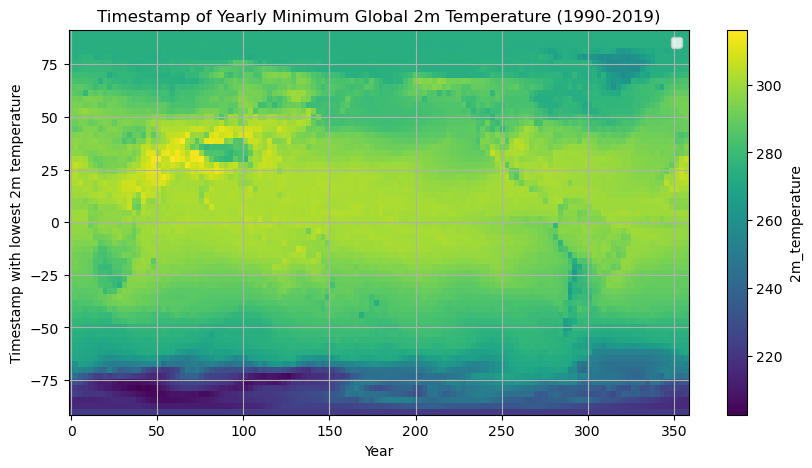

850
1991-08-01 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


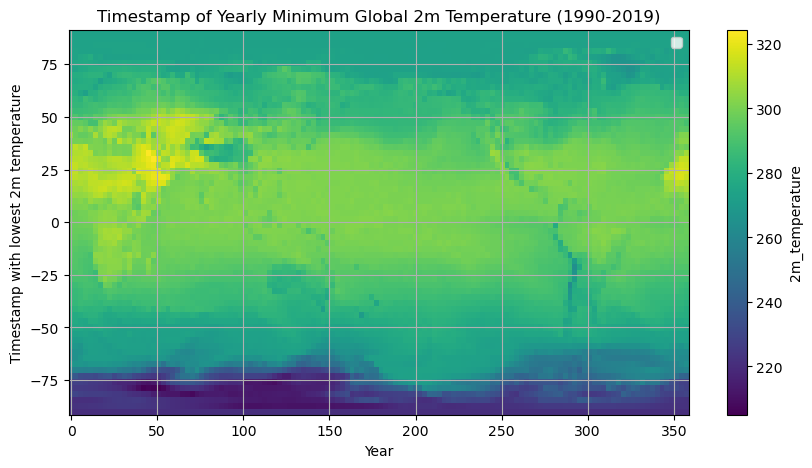

726
1992-06-30 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


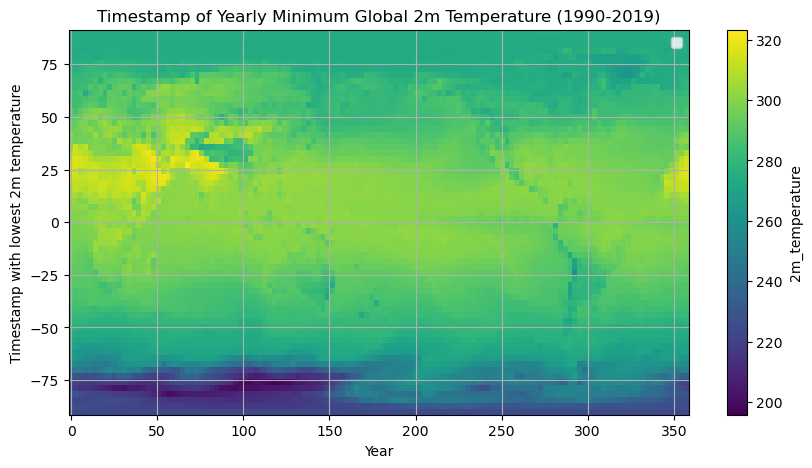

754
1993-07-08 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


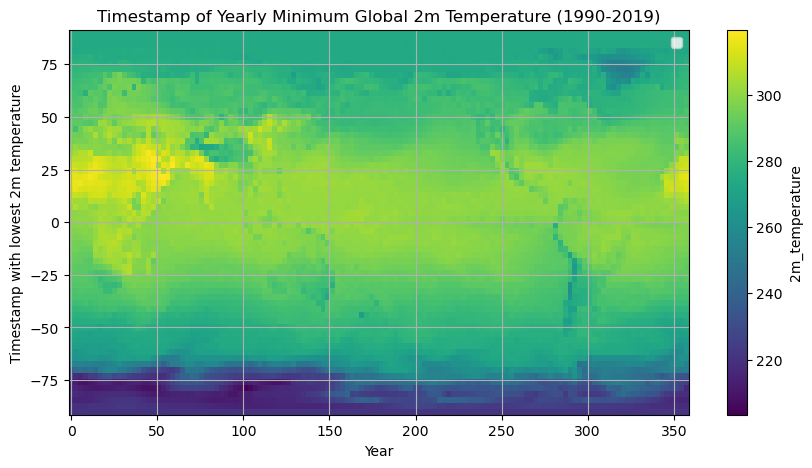

766
1994-07-11 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


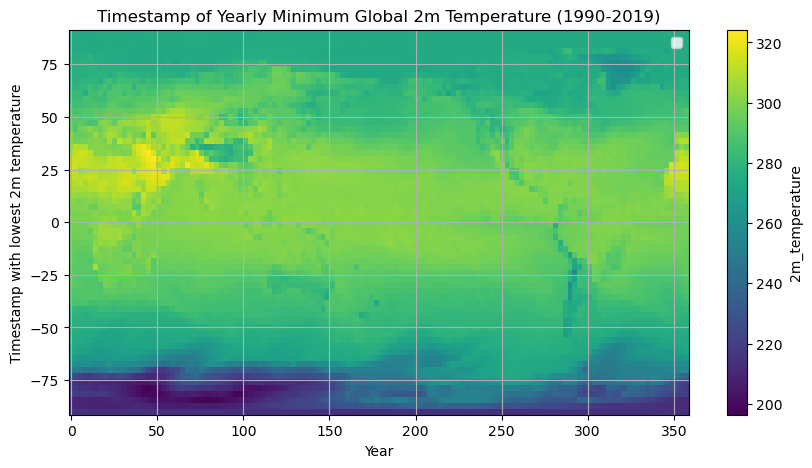

822
1995-07-25 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


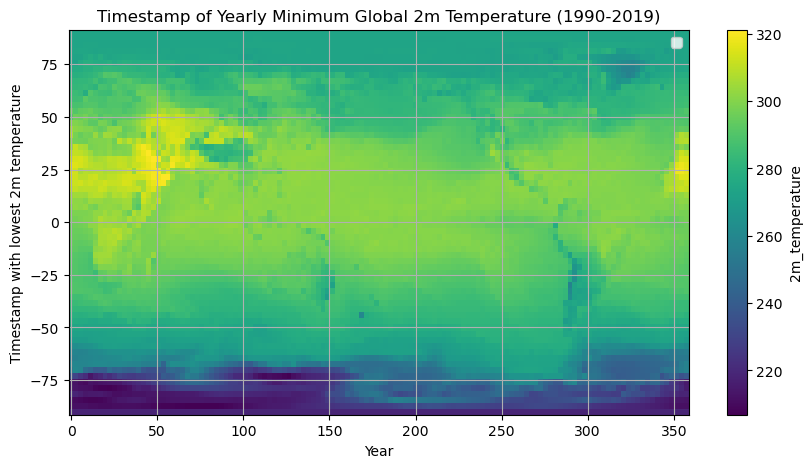

746
1996-07-05 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


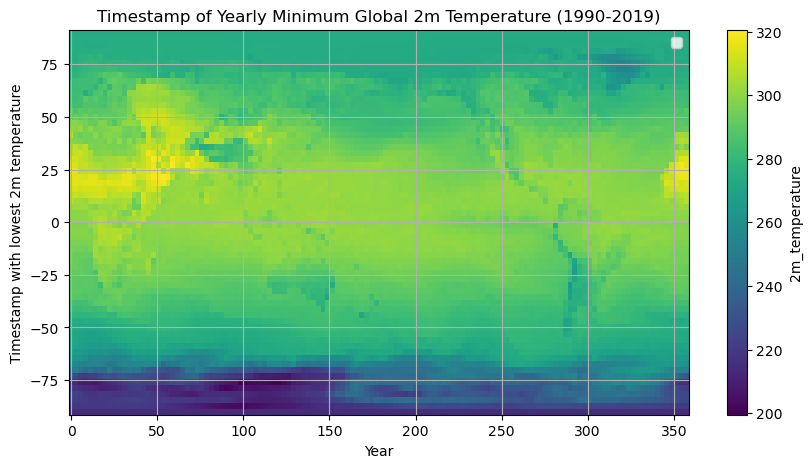

557
1997-05-20 06:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


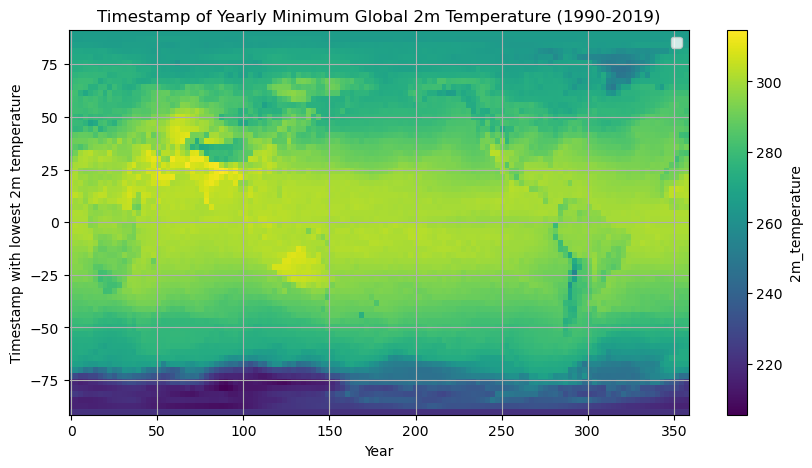

853
1998-08-02 06:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


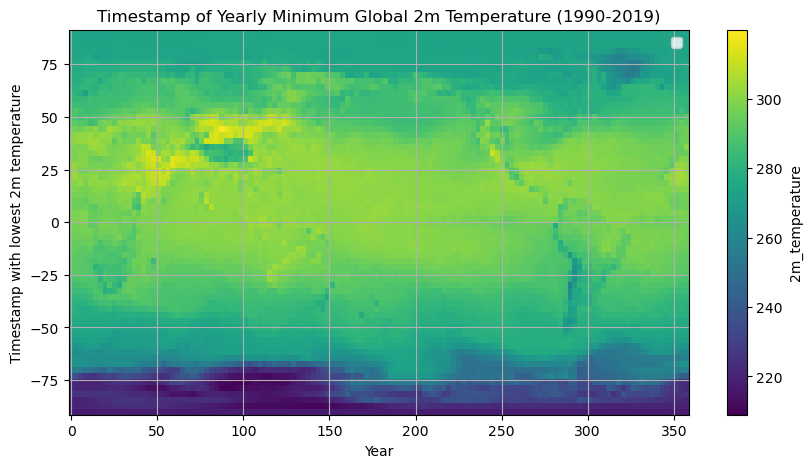

814
1999-07-23 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


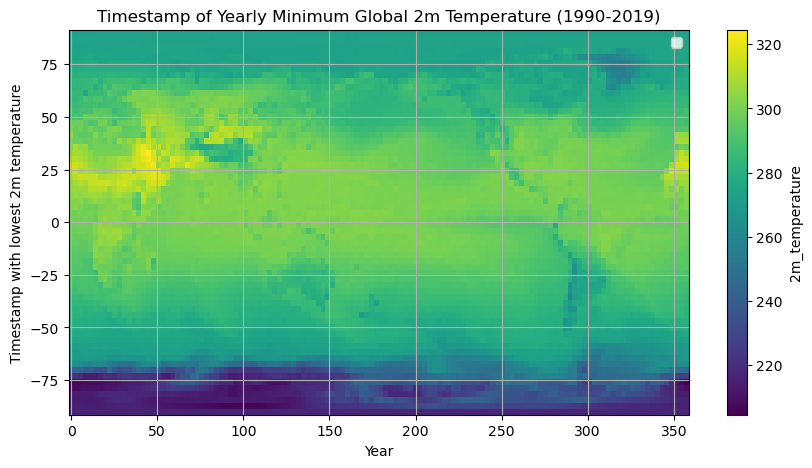

606
2000-05-31 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


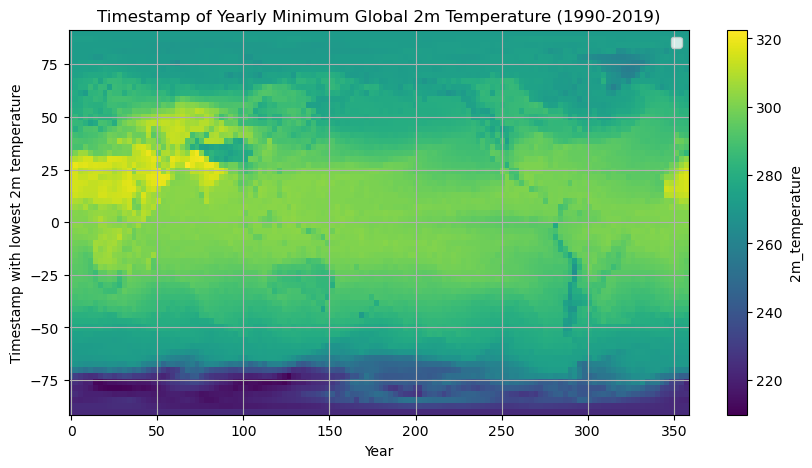

998
2001-09-07 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


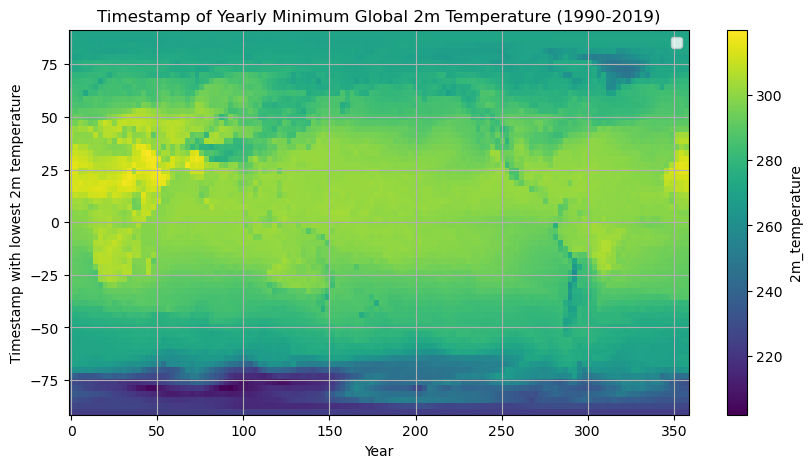

638
2002-06-09 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


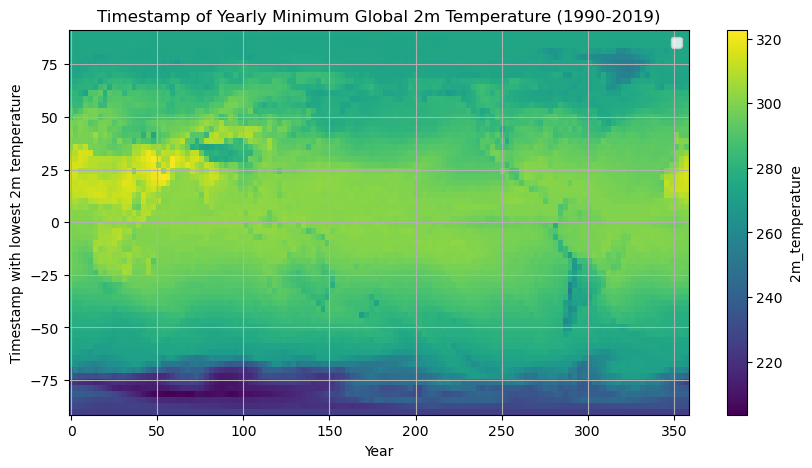

858
2003-08-03 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


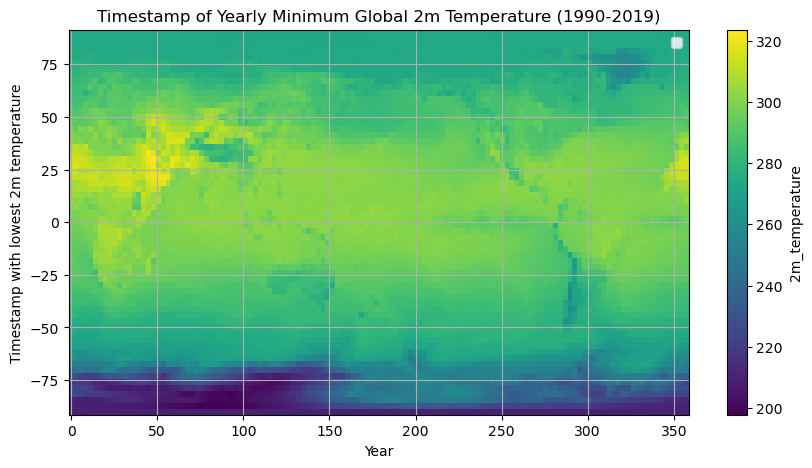

630
2004-06-06 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


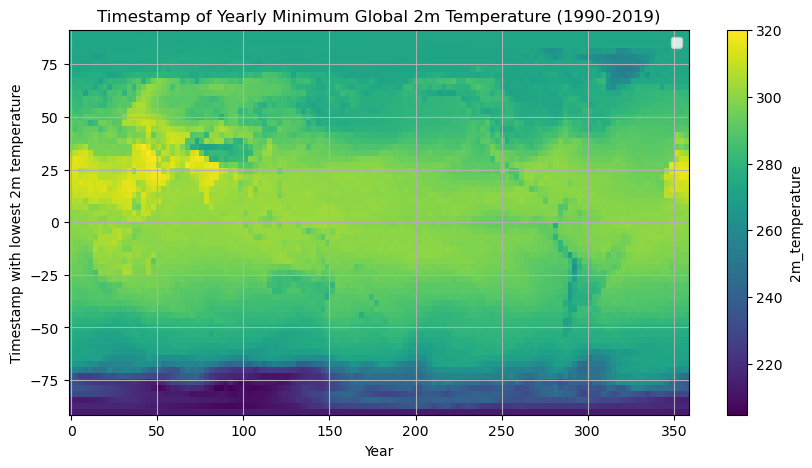

666
2005-06-16 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


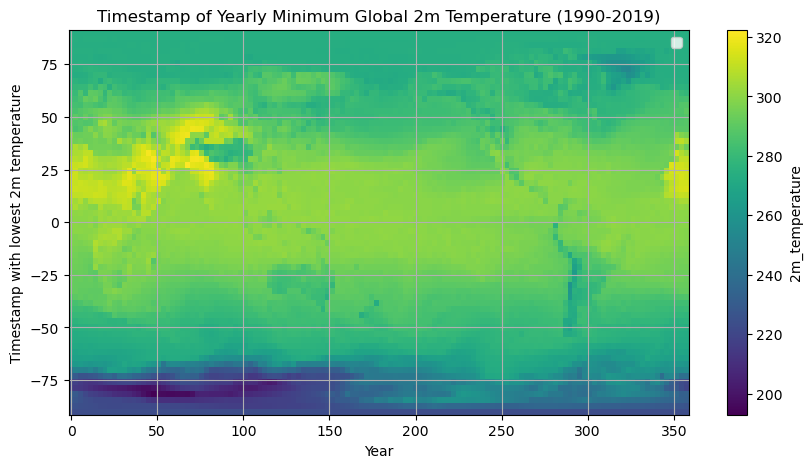

1037
2006-09-17 06:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


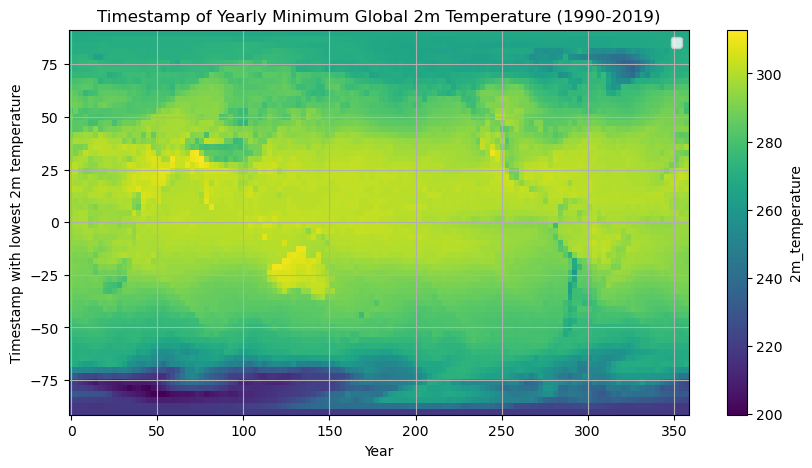

842
2007-07-30 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


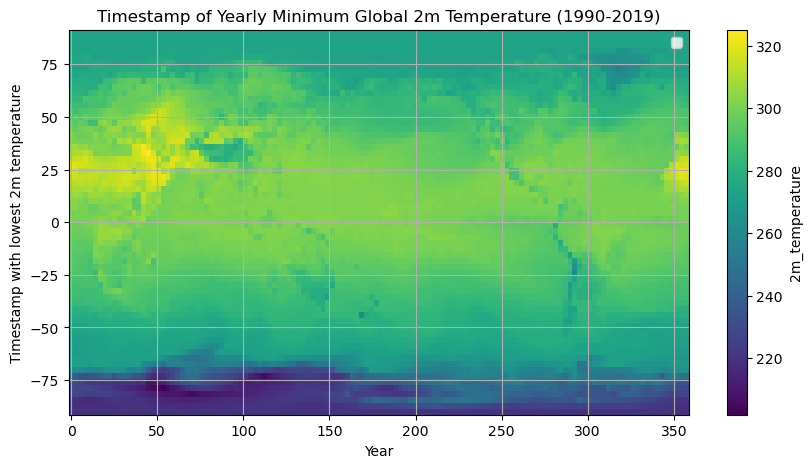

682
2008-06-19 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


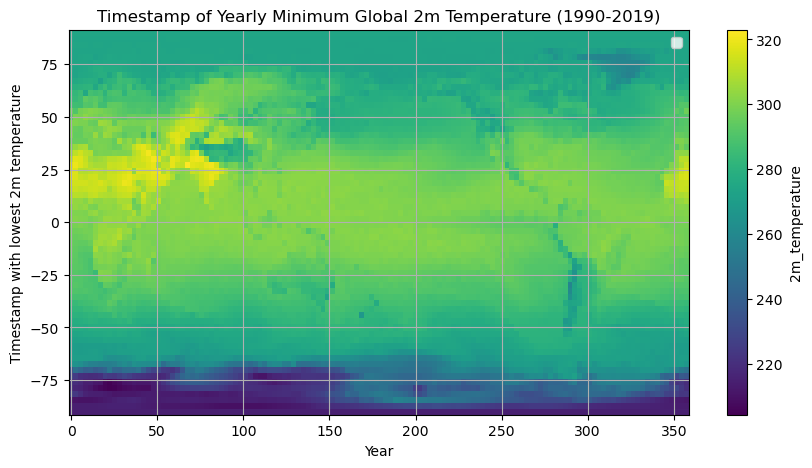

677
2009-06-19 06:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


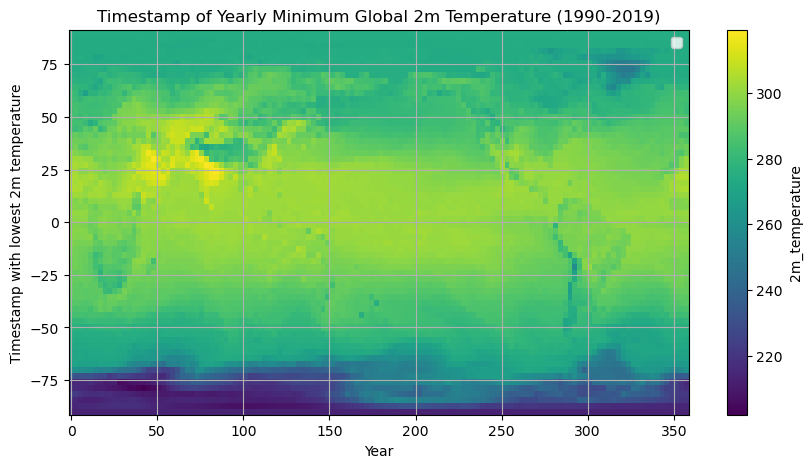

613
2010-06-03 06:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


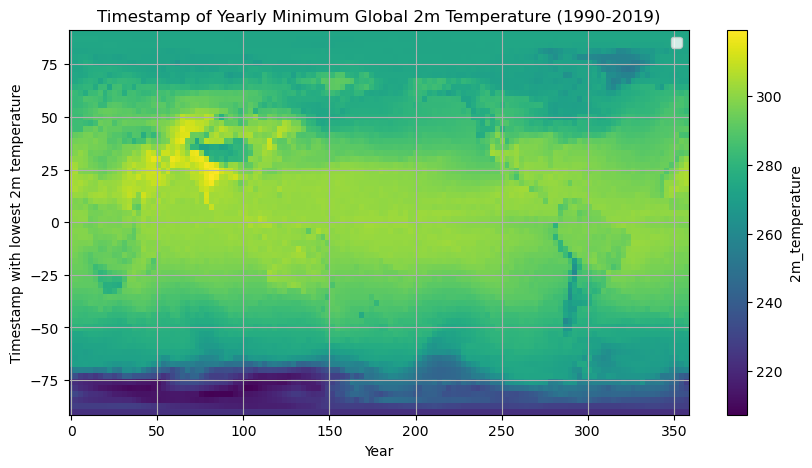

810
2011-07-22 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


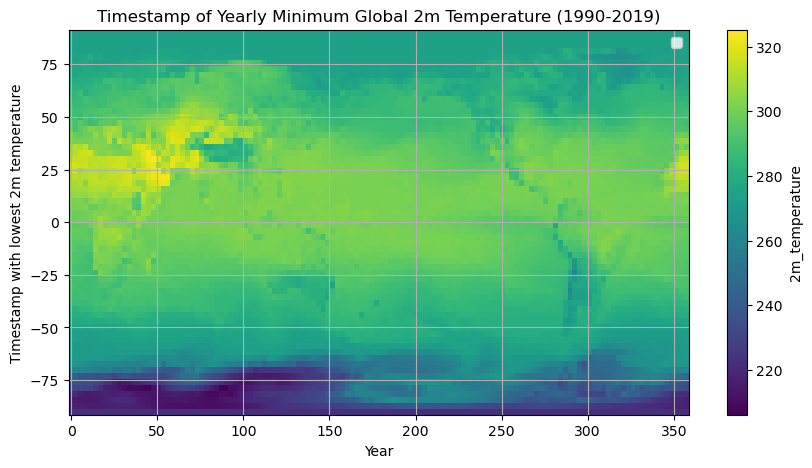

806
2012-07-20 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


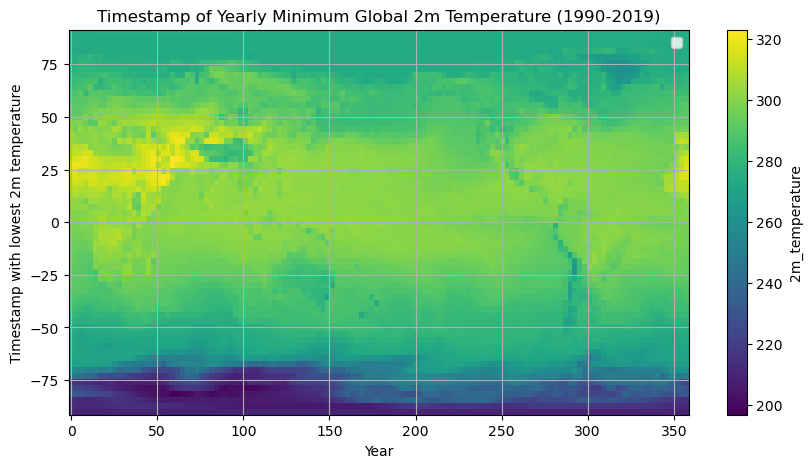

846
2013-07-31 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


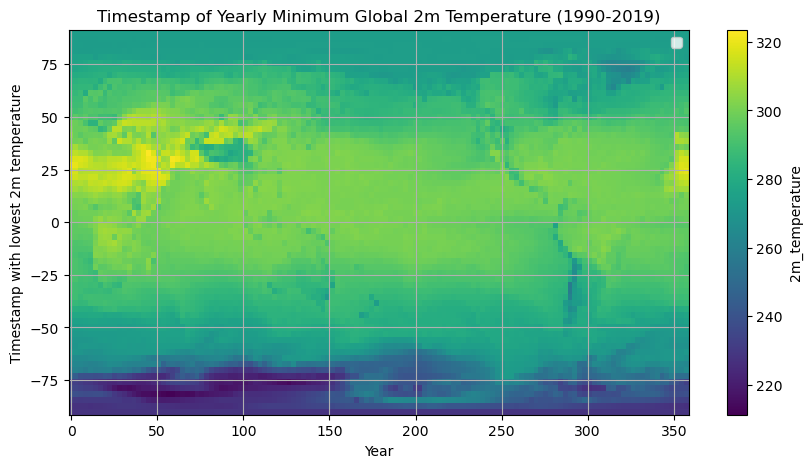

918
2014-08-18 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


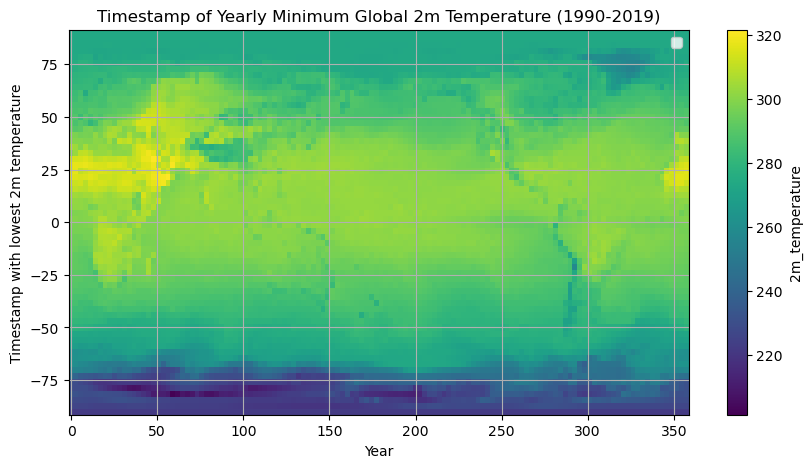

714
2015-06-28 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


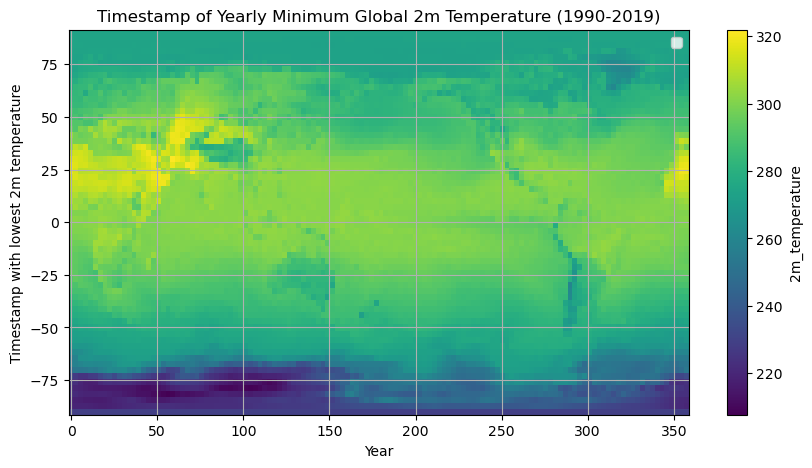

770
2016-07-11 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


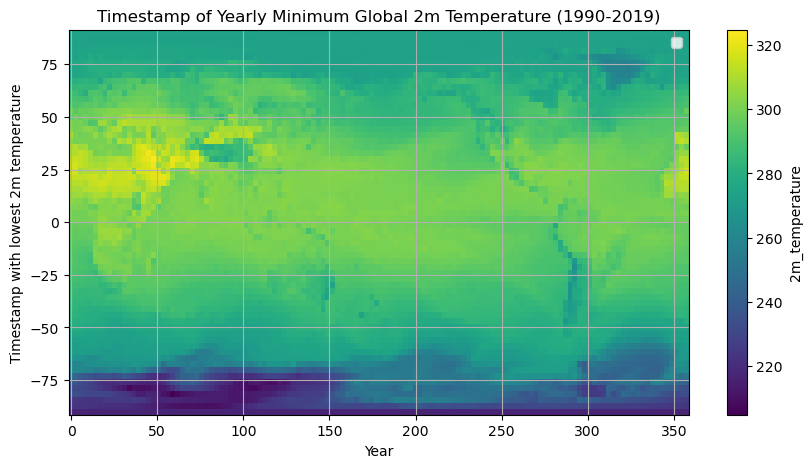

834
2017-07-28 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


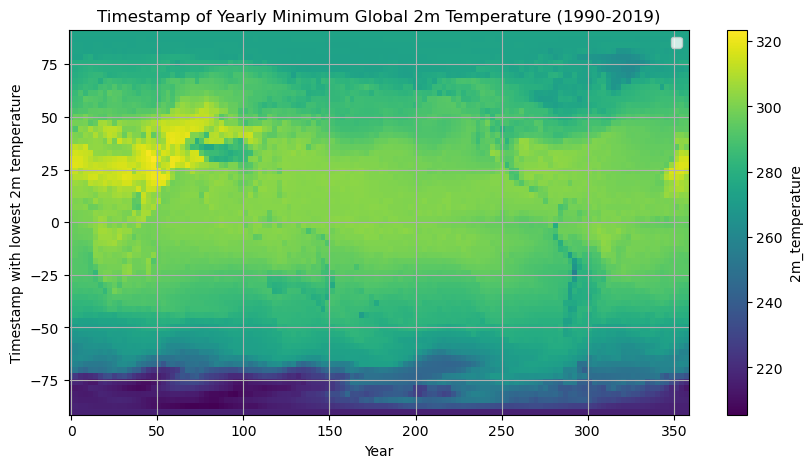

738
2018-07-04 12:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


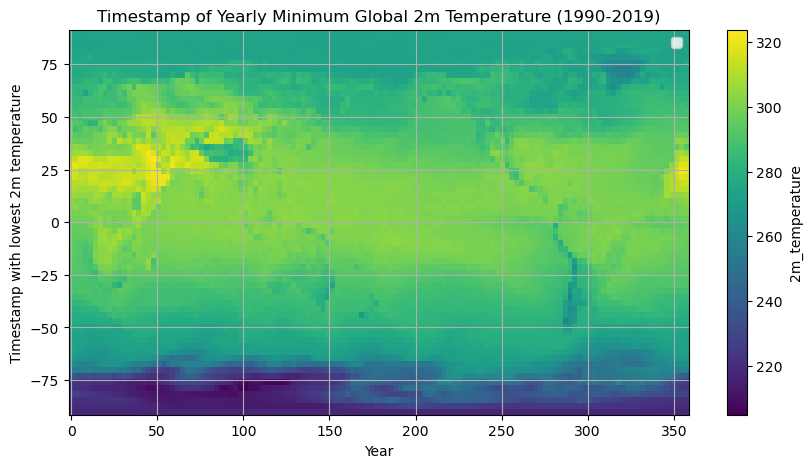

821
2019-07-25 06:00:00


/scratch/ipykernel_856937/2048558023.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


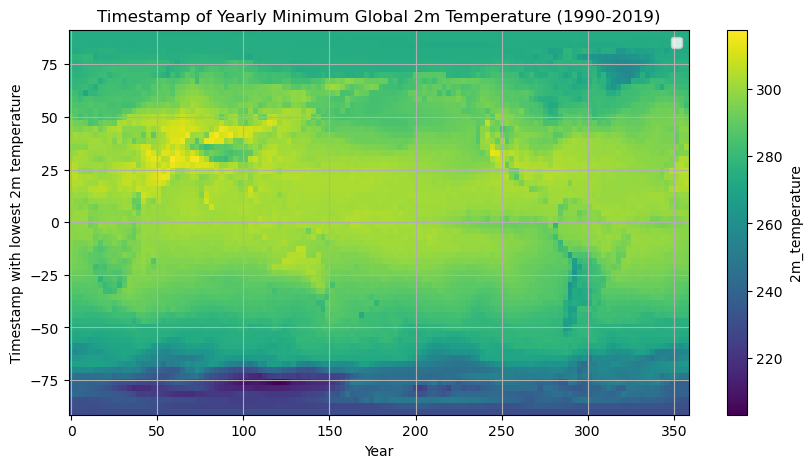

In [46]:
for year in range(1990, 2020):
    plot_lowest_val_timestamp(ds_nextgems, '2m_temperature', year)

Variable: geopotential, year: 1990


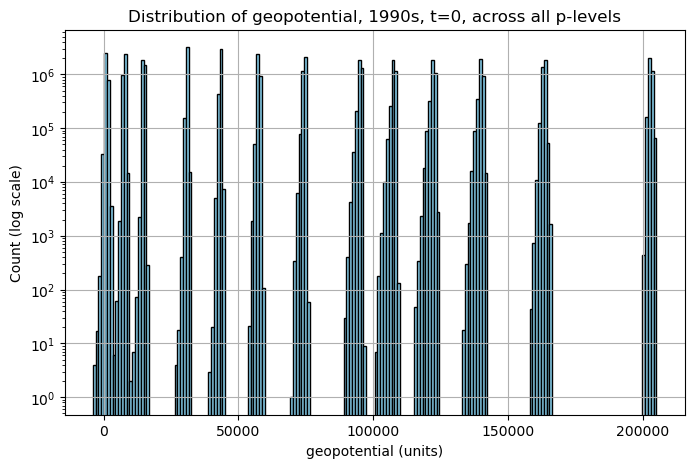

Min: -3971.7114
Max: 205057.98
Mean: 81567.46
Std: 60975.734
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 1991


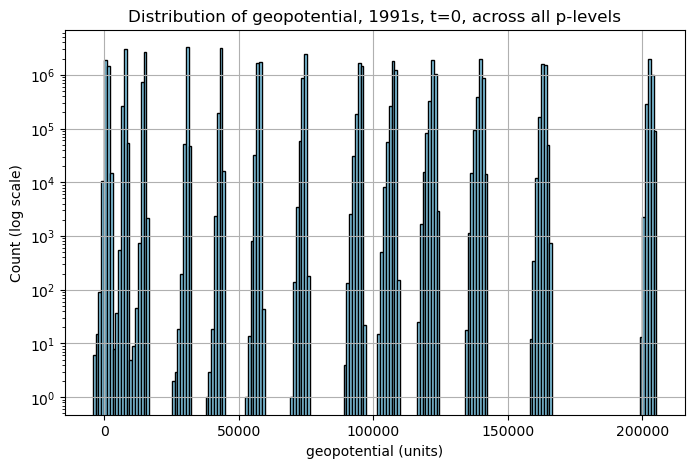

Min: -4186.9463
Max: 205217.56
Mean: 81578.2
Std: 60980.29
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 1992


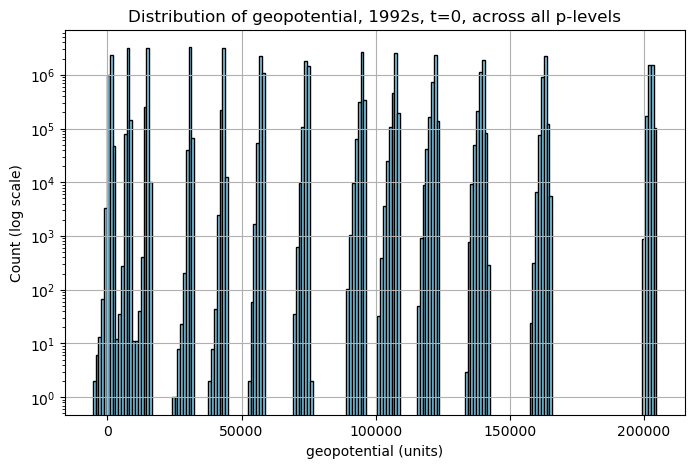

Min: -5455.511
Max: 204759.98
Mean: 81452.39
Std: 60886.35
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 1993


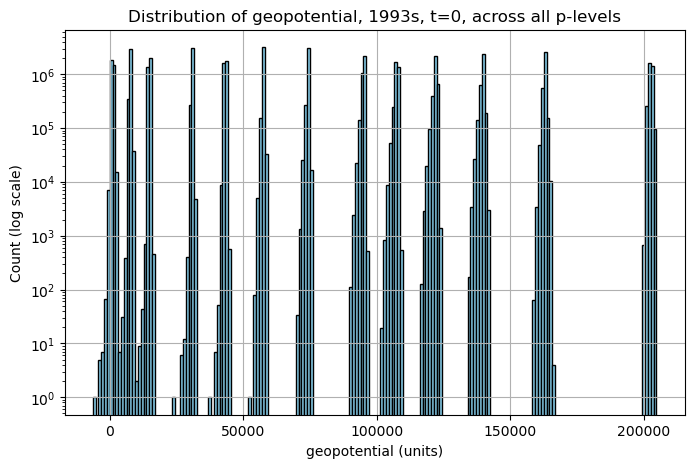

Min: -6350.484
Max: 204737.19
Mean: 81443.98
Std: 60861.8
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 1994


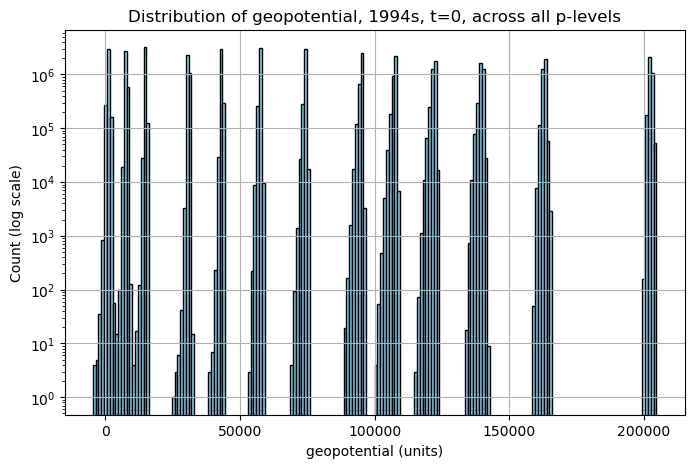

Min: -4621.213
Max: 204677.4
Mean: 81405.56
Std: 60822.58
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 1995


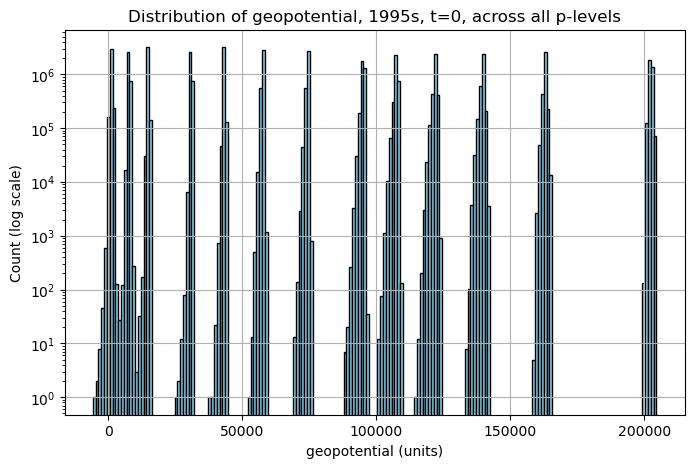

Min: -5786.7017
Max: 204535.97
Mean: 81430.63
Std: 60836.984
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 1996


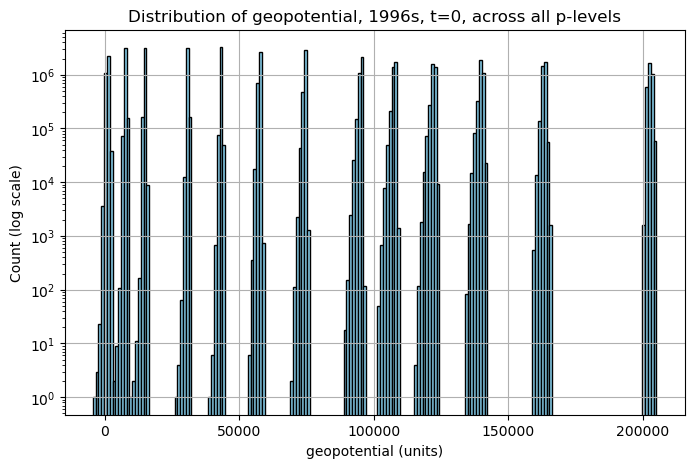

Min: -4367.655
Max: 204977.39
Mean: 81504.67
Std: 60902.188
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 1997


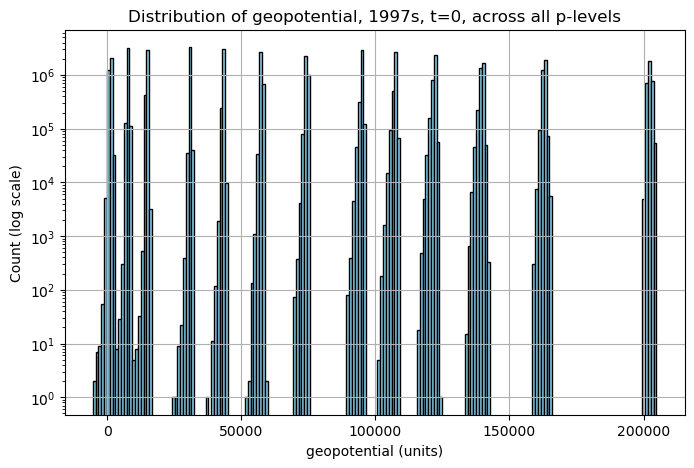

Min: -5400.1445
Max: 204823.0
Mean: 81414.14
Std: 60813.703
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 1998


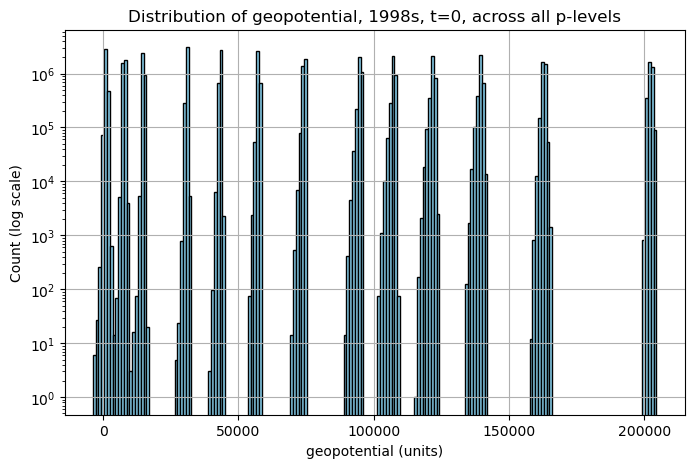

Min: -3812.545
Max: 204486.2
Mean: 81356.36
Std: 60787.453
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 1999


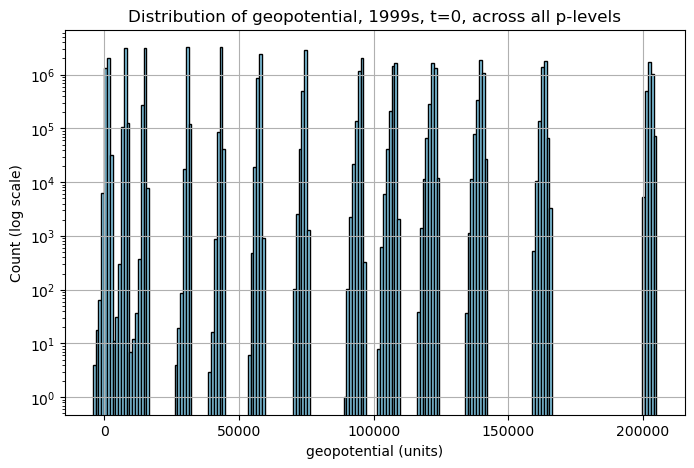

Min: -4300.343
Max: 205047.25
Mean: 81548.26
Std: 60929.16
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 2000


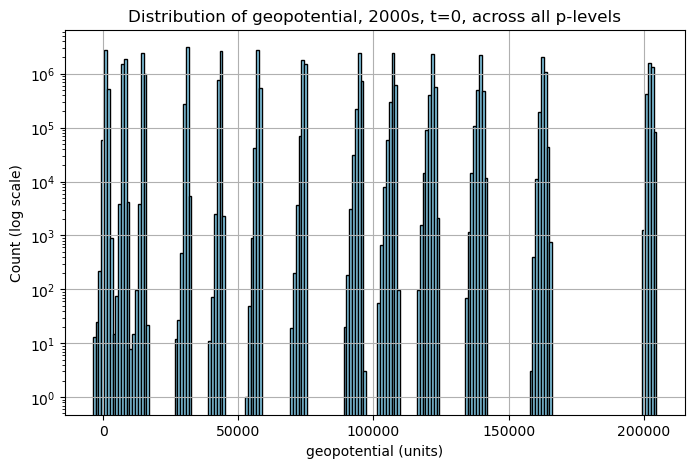

Min: -3837.0056
Max: 204722.44
Mean: 81396.07
Std: 60823.766
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 2001


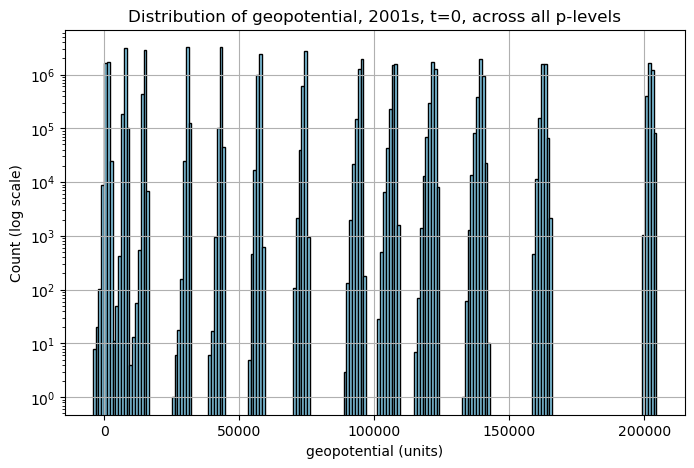

Min: -4238.3076
Max: 204539.92
Mean: 81354.79
Std: 60784.977
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 2002


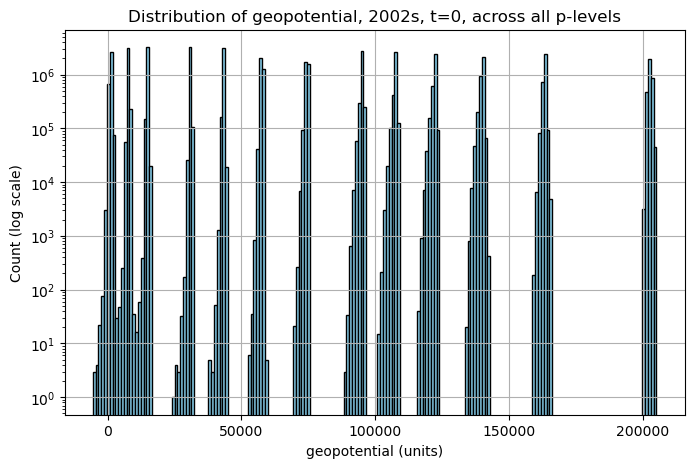

Min: -5560.9033
Max: 205208.44
Mean: 81588.84
Std: 60971.86
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 2003


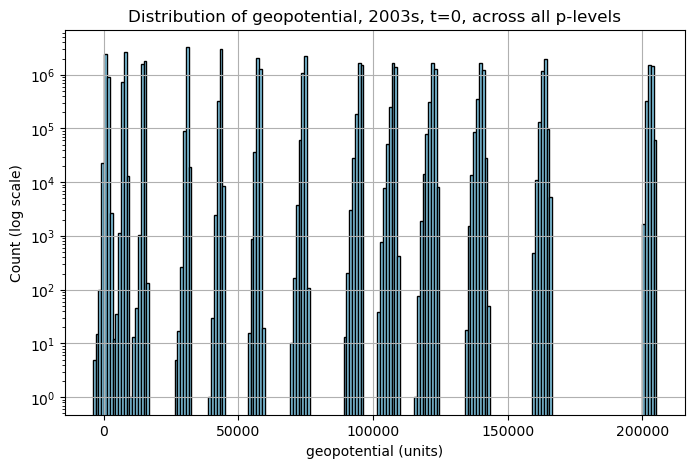

Min: -4009.8784
Max: 205192.16
Mean: 81657.23
Std: 61030.8
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 2004


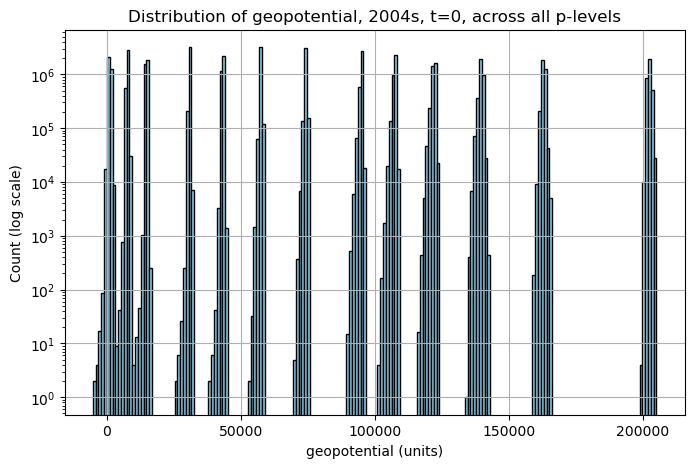

Min: -5205.5483
Max: 205052.23
Mean: 81396.33
Std: 60822.793
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 2005


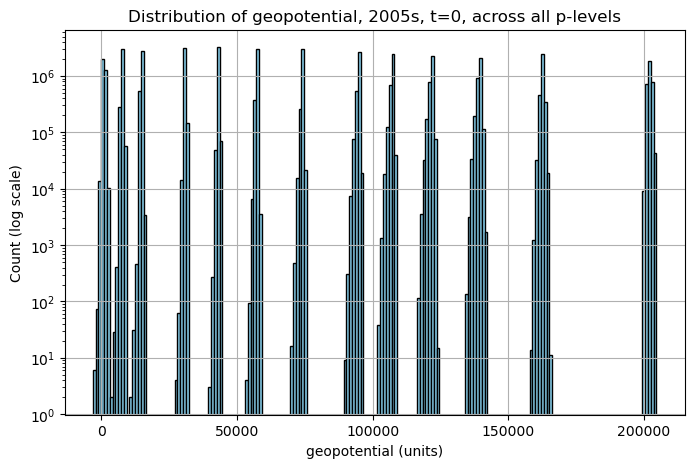

Min: -3059.3884
Max: 204550.84
Mean: 81263.92
Std: 60696.42
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 2006


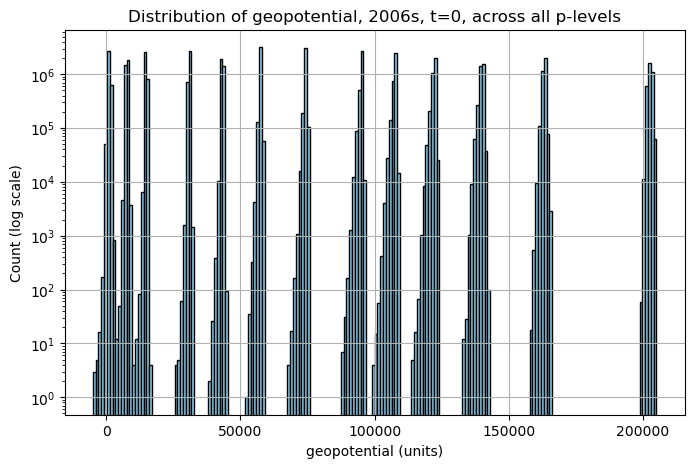

Min: -4961.6987
Max: 205018.5
Mean: 81514.234
Std: 60909.113
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 2007


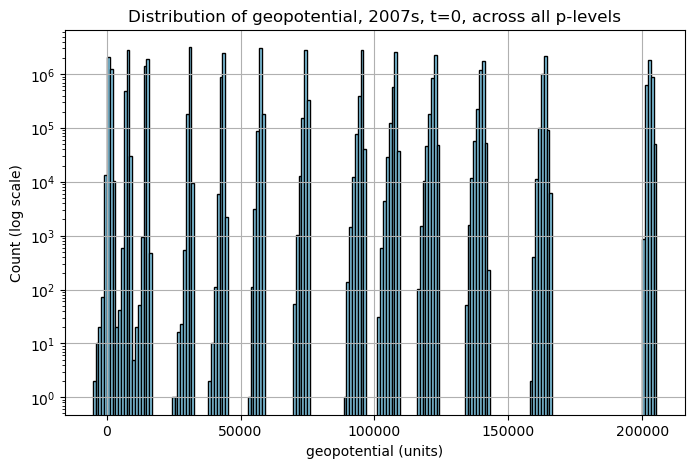

Min: -5190.084
Max: 205357.98
Mean: 81647.71
Std: 61001.95
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 2008


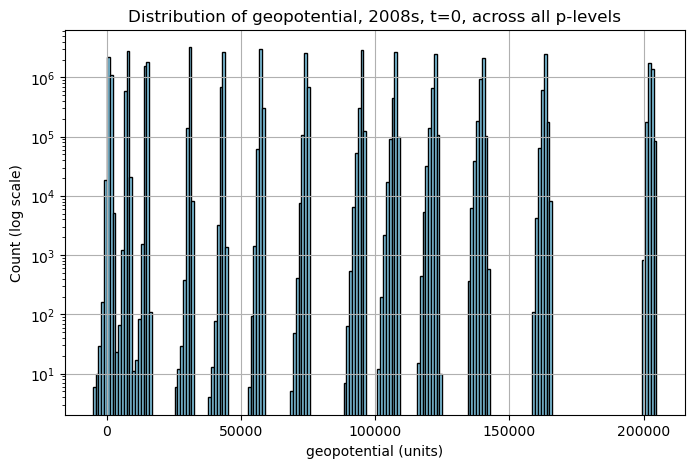

Min: -5151.013
Max: 204809.2
Mean: 81536.695
Std: 60925.676
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 2009


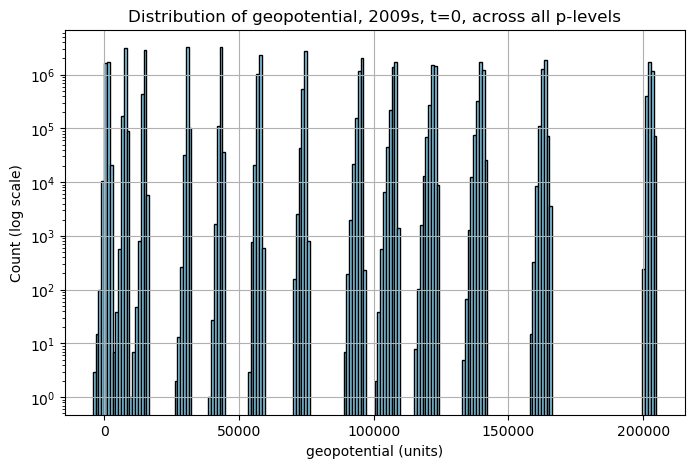

Min: -4226.345
Max: 204937.08
Mean: 81538.03
Std: 60917.93
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 2010


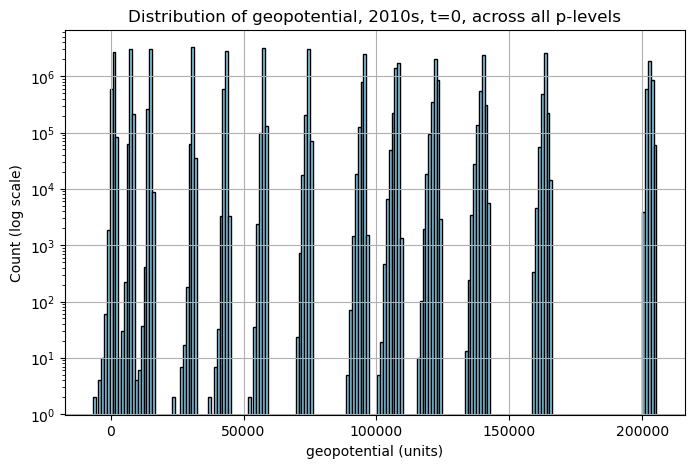

Min: -6667.679
Max: 205318.62
Mean: 81619.234
Std: 60987.418
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 2011


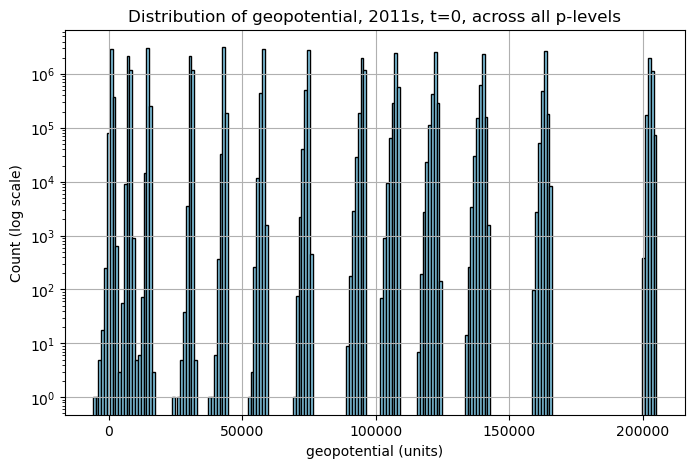

Min: -5921.2563
Max: 205054.92
Mean: 81589.07
Std: 60962.125
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 2012


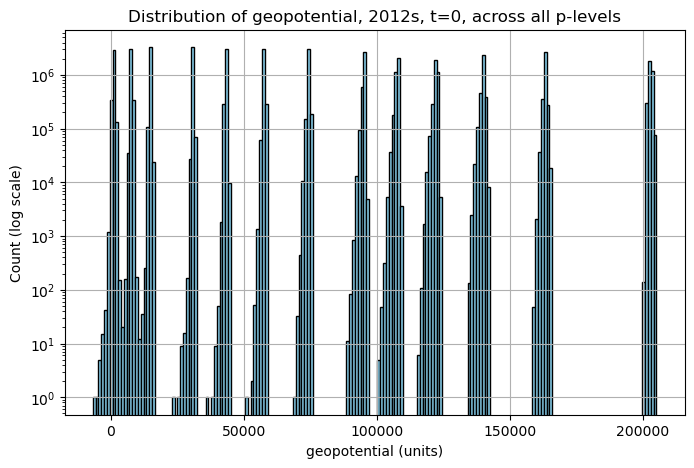

Min: -6758.064
Max: 205203.55
Mean: 81628.414
Std: 60999.01
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 2013


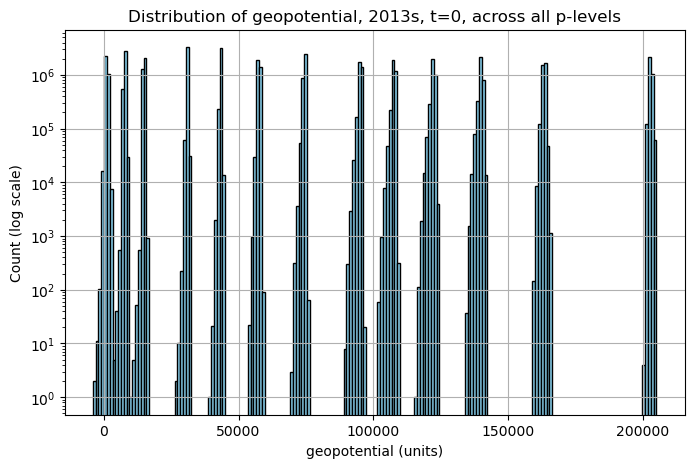

Min: -4064.7349
Max: 205016.23
Mean: 81545.76
Std: 60941.25
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 2014


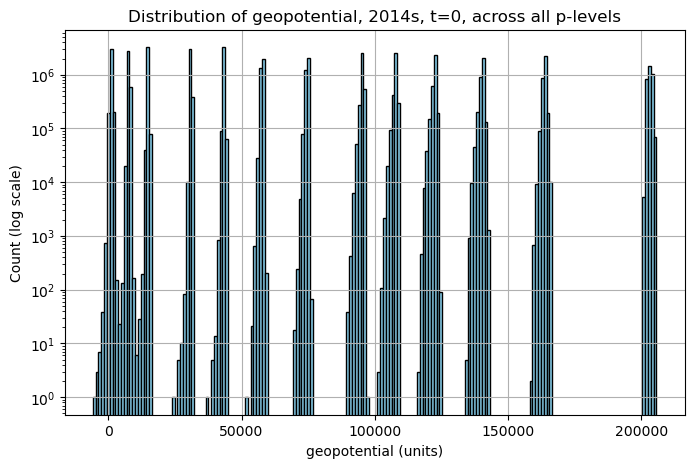

Min: -5775.476
Max: 205644.25
Mean: 81740.3
Std: 61088.55
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 2015


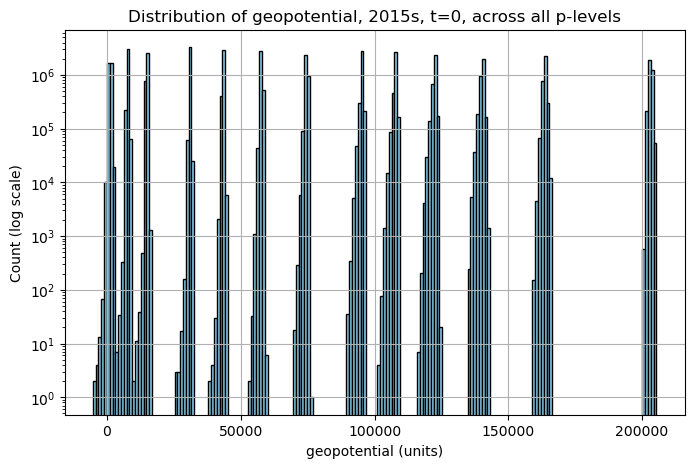

Min: -5318.4326
Max: 205377.28
Mean: 81735.3
Std: 61085.42
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 2016


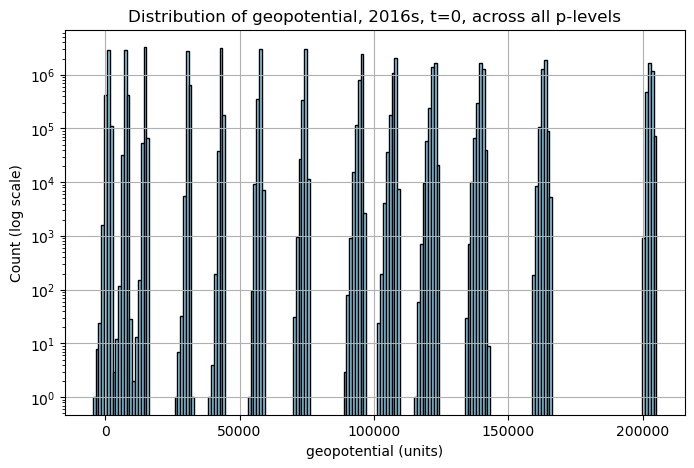

Min: -4561.823
Max: 205105.8
Mean: 81572.25
Std: 60962.66
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 2017


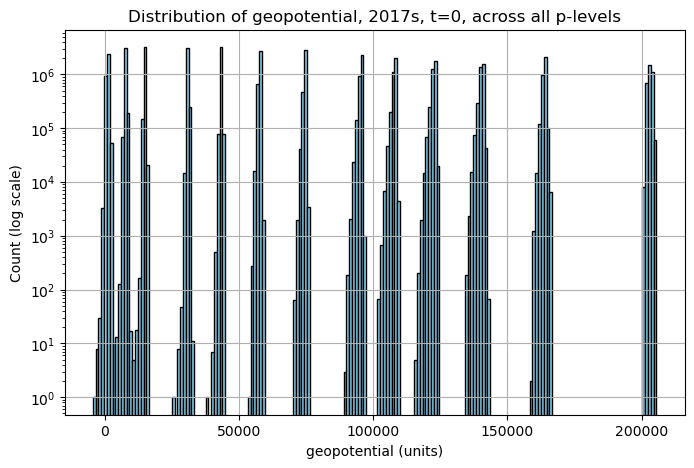

Min: -4415.7646
Max: 205486.16
Mean: 81740.44
Std: 61085.723
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 2018


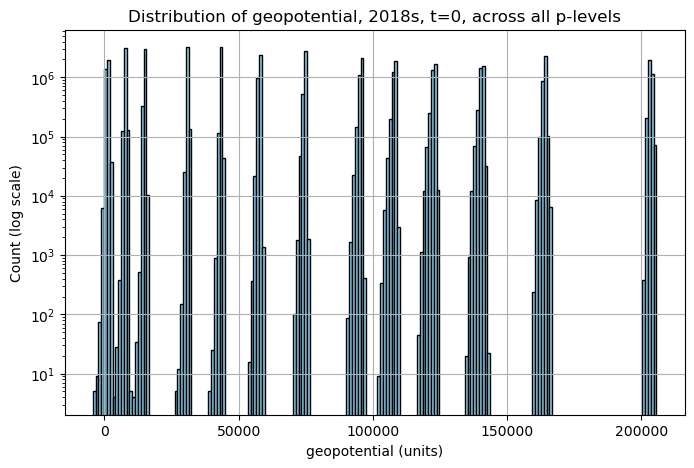

Min: -4317.2275
Max: 205659.44
Mean: 81830.664
Std: 61168.414
Number of NaNs: 0
------------------------------

Variable: geopotential, year: 2019


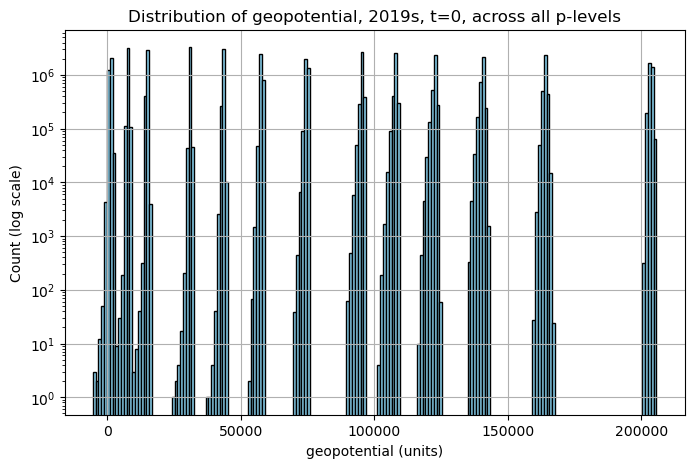

Min: -5421.6084
Max: 205614.53
Mean: 81856.734
Std: 61192.633
Number of NaNs: 0
------------------------------



In [47]:
for year in range(1990, 2020):
    plot_distribution_per_year(ds_nextgems.sel(latitude=slice(-25,25)), '2m_temperature', year, False)

In [8]:
ds_era5_short.chunk({'time': 40}).to_zarr("/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_era5_1990_2020_6h-128x64_equiangular_with_poles_conservative/fields.zarr", mode='w')

In [13]:
base = "/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextGEMS_1990_2020_6h-128x64_transposed_nans_filled_f32/"

ds = xr.open_dataset(base+"fields.zarr")
ds_era5_short = xr.open_dataset("/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_era5_1990_2020_6h-128x64_equiangular_with_poles_conservative/fields.zarr")
print(ds)
print(ds_era5_short)

<xarray.Dataset> Size: 119GB
Dimensions:                  (time: 43828, longitude: 128, latitude: 64,
                              level: 13)
Coordinates:
  * latitude                 (latitude) float64 512B -90.0 -87.14 ... 87.14 90.0
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * longitude                (longitude) float64 1kB 0.0 2.812 ... 354.4 357.2
  * time                     (time) datetime64[ns] 351kB 1990-01-01 ... 2019-...
Data variables: (12/13)
    10m_u_component_of_wind  (time, longitude, latitude) float32 1GB ...
    10m_v_component_of_wind  (time, longitude, latitude) float32 1GB ...
    2m_temperature           (time, longitude, latitude) float32 1GB ...
    geopotential             (time, level, longitude, latitude) float32 19GB ...
    geopotential_at_surface  (longitude, latitude) float32 33kB ...
    land_sea_mask            (longitude, latitude) float32 33kB ...
    ...                       ...
    specific_humidity        

/home/hk-project-pai00005/xo8179/miniconda3/envs/regridding/lib/python3.10/site-packages/xarray/backends/api.py:651: RuntimeWarning: 'netcdf4' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)
/home/hk-project-pai00005/xo8179/miniconda3/envs/regridding/lib/python3.10/site-packages/xarray/backends/api.py:651: RuntimeWarning: 'netcdf4' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)


In [12]:
import xarray as xr
import numpy as np

# Open with chunking to avoid OOM
ds = xr.open_zarr(base+"fields.zarr", chunks={'time': 16})

# Convert variables to float32 where applicable
ds_float32 = ds.copy()

for var in ds.data_vars:
    if np.issubdtype(ds[var].dtype, np.floating) and ds[var].dtype == np.float64:
        print(f"Converting {var} from float64 to float32")
        ds_float32[var] = ds[var].astype(np.float32)

# Write to a new Zarr store with appropriate chunking
ds_float32.to_zarr(
    "/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextGEMS_1990_2020_6h-128x64_transposed_nans_filled_f32/fields.zarr",
    mode='w'
)

Converting 10m_u_component_of_wind from float64 to float32
Converting 10m_v_component_of_wind from float64 to float32
Converting 2m_temperature from float64 to float32
Converting geopotential from float64 to float32
Converting mean_sea_level_pressure from float64 to float32
Converting specific_humidity from float64 to float32
Converting temperature from float64 to float32
Converting total_precipitation_6hr from float64 to float32
Converting u_component_of_wind from float64 to float32
Converting v_component_of_wind from float64 to float32
Converting vertical_velocity from float64 to float32


In [53]:
import zarr
def fill_geopotential_nans(
    zarr_path,
    coords_and_values,
    variable="geopotential",
):
    """
    Fill NaNs at known coordinates for the 'geopotential' variable in a Zarr file.

    Parameters:
    - zarr_path: path to the Zarr store
    - variable: variable name inside Zarr store (default: "geopotential")
    - coords_and_values: list of tuples:
          [ ((t_idx, y_idx, x_idx), value_to_fill), ... ]
    """
    z = zarr.open(zarr_path, mode='r+')
    var = z[variable]

    for (t_idx, l_index, y_idx, x_idx), value_to_fill in coords_and_values:
        current_value = var[t_idx, l_index, y_idx, x_idx]
        if np.isnan(current_value):
            var[t_idx, l_index, y_idx, x_idx] = value_to_fill
            print(f"Filled NaN at ({t_idx}, {l_index}, {y_idx}, {x_idx}) with {value_to_fill}")
        else:
            print(f"No NaN at ({t_idx}, {l_index}, {y_idx}, {x_idx}); current value is {current_value}, skipping.")

In [82]:
vtime=41687
vlevel=10
vlon=34
vlat=9
ds = xr.open_zarr("/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextGEMS_1990_2020_6h-128x64_transposed_nans_filled/fields.zarr")
fill_val = ds["geopotential"].isel(time=vtime, longitude=slice(vlon-1,vlon+2), latitude=slice(vlat-1,vlat+2), level=vlevel).sum(skipna=True).values/8
print(fill_val)

11231.556596662045


In [81]:
coords_to_fix = [
    ((vtime, vlevel, vlon, vlat), fill_val),
]

fill_geopotential_nans("/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextGEMS_1990_2020_6h-128x64_transposed_nans_filled/fields.zarr", coords_and_values=coords_to_fix)

Filled NaN at (41687, 10, 34, 9) with 9983.605863699595


In [83]:
import pandas as pd
var = "geopotential"
nan_locations = []

da = ds[var]
mask = np.isnan(da)

if mask.any():
    # Get indexes of NaNs
    idxs = np.argwhere(mask.values)
    for idx in idxs:
        # Extract coordinates for each NaN
        coords = {}
        for axis, dim in enumerate(da.dims):
            coord_val = da[dim].values[idx[axis]]
            coords[dim] = idx[axis]
        nan_locations.append(coords)

# Convert to DataFrame for easy viewing
df_nan_locations = pd.DataFrame(nan_locations)
print(df_nan_locations)

Empty DataFrame
Columns: []
Index: []


In [32]:
def fill_nan_timestamp_zarr(ds, var, timestamp):
    da = ds[var].sel(time=timestamp)
    mask_nan = np.isnan(da)

    if not mask_nan.any():
        print(f"No NaNs in {timestamp}")
        return

    print(da)
    # Fill using nearest neighbor interpolation
    da_filled = da.interpolate_na(
        dim="longitude",
        method="linear",
        fill_value="interpolate"
    )

    # Write back only the timestamp
    result = da_filled.sel(longitude=334.6875, latitude=-70)
    print(result.values)
    ds[var].loc[dict(time=timestamp)] = result

    print(f"Filled NaNs for {var} at {timestamp}")

# Usage:
ds = xr.open_zarr("/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextGEMS_1990_2020_6h-128x64_transposed_nans_filled/" + "fields.zarr")
fill_nan_timestamp_zarr(ds, "geopotential", np.datetime64(713102400000000000, "ns"))

<xarray.DataArray 'geopotential' (level: 13, longitude: 128, latitude: 64)> Size: 852kB
dask.array<getitem, shape=(13, 128, 64), dtype=float64, chunksize=(13, 128, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 512B -90.0 -87.14 -84.29 ... 84.29 87.14 90.0
  * level      (level) int64 104B 50 100 150 200 250 ... 600 700 850 925 1000
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
    time       datetime64[ns] 8B 1992-08-06T12:00:00
Attributes:
    regrid_method:  bilinear


TypeError: must be real number, not str

In [ ]:
# print(ds)
# print(np.unique(ds['lon'].values))
# ds['lon'] = ds['lon'] % 360
# print(np.unique(ds['lon'].values))

<xarray.Dataset> Size: 2TB
Dimensions:  (time: 14608, level: 13, value: 1038240)
Coordinates:
  * time     (time) int64 117kB 1262304000 1262325600 ... 1577793600 1577815200
  * level    (level) int64 104B 50 100 150 200 250 300 ... 600 700 850 925 1000
    lon      (value) float64 8MB dask.array<chunksize=(1038240,), meta=np.ndarray>
    lat      (value) float64 8MB dask.array<chunksize=(1038240,), meta=np.ndarray>
Dimensions without coordinates: value
Data variables:
    t        (time, level, value) float64 2TB dask.array<chunksize=(16, 13, 1038240), meta=np.ndarray>
Attributes:
    edition:            2
    centre:             ecmf
    centreDescription:  European Centre for Medium-Range Weather Forecasts
    subCentre:          1003
    history:            🪄🧙‍♂️🔮 magic dataset assembly provided by gribscan.IF...
[-180.   -179.75 -179.5  ...  179.25  179.5   179.75]
[0.0000e+00 2.5000e-01 5.0000e-01 ... 3.5925e+02 3.5950e+02 3.5975e+02]


In [ ]:
# # Fix lons and lats
# ds['lon'] = ds['lon'] % 360
# ds = ds.sortby('lat')

# # Reshape if confident about ordering:
# lat_len = len(np.unique(ds['lat'].values))
# lon_len = len(np.unique(ds['lon'].values))
# t_reshaped = ds['t'].data.reshape(ds.dims['time'], ds.dims['level'], lat_len, lon_len)

# ds_final = xr.Dataset(
#     {'t': (('time', 'level', 'lat', 'lon'), t_reshaped)},
#     coords={
#         'time': ds['time'],
#         'level': ds['level'],
#         'lat': np.sort(np.unique(ds['lat'].values)),
#         'lon': np.sort(np.unique(ds['lon'].values))
#     }
# )

/scratch/ipykernel_1843322/3947599840.py:8: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  t_reshaped = ds['t'].data.reshape(ds.dims['time'], ds.dims['level'], lat_len, lon_len)


In [ ]:

# target_lon = np.arange(0, 360, 2.8125)
# target_lat = np.linspace(-90, 90, 64)
# target_grid = xr.Dataset({
#     'lat': (['lat'], target_lat),
#     'lon': (['lon'], target_lon)
# })


# import xesmf as xe

# print("Defined grid")
# # 3. Create regridder (adjust variable as needed)
# regridder = xe.Regridder(ds_final, target_grid, 'bilinear', periodic=True)
# print("Regridding....")

# # 4. Apply regridding
# ds_regridded = regridder(ds_final['t'])
# ds_regridded = ds_regridded.to_dataset(name='t')

Defined grid
Regridding....


In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_map(ds, var, timestamp):
    fig = plt.figure(figsize=(10, 5))

    # Use PlateCarree projection for simple lat-lon data
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Add coastlines for reference
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    # Plot the data
    # Use pcolormesh for speed and clarity
    data = ds[var].sel(time=timestamp, level=1000)
    # print(data)
    mesh = data.plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),  # Data's native projection
        cmap='viridis',                # adjust to taste
        add_colorbar=True,
        add_labels=False
    )
    ax.set_title('Regridded Temperature (t)')

    plt.show()

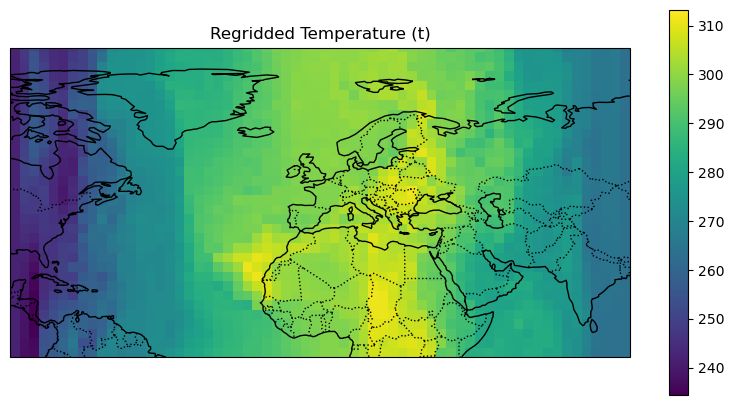

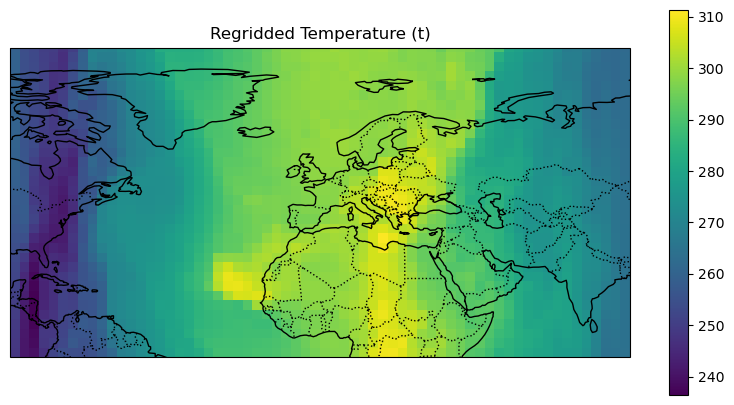

In [6]:
plot_map(ds, "temperature", "1990-10-01T00:00:00")
plot_map(ds_era5, "temperature", "1990-10-01T00:00:00")

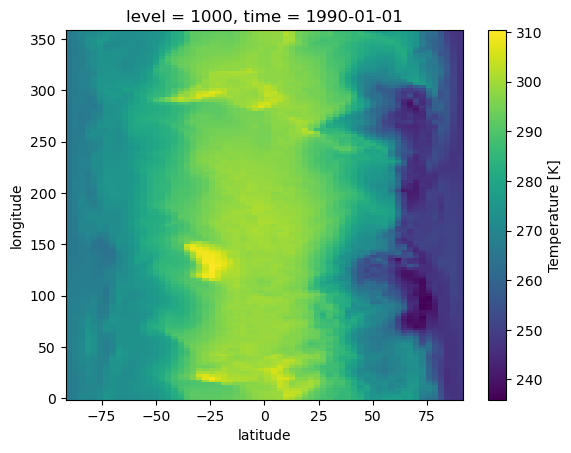

In [18]:
ds_era5["temperature"].sel(time="1990-01-01T00:00:00", level=1000).plot()


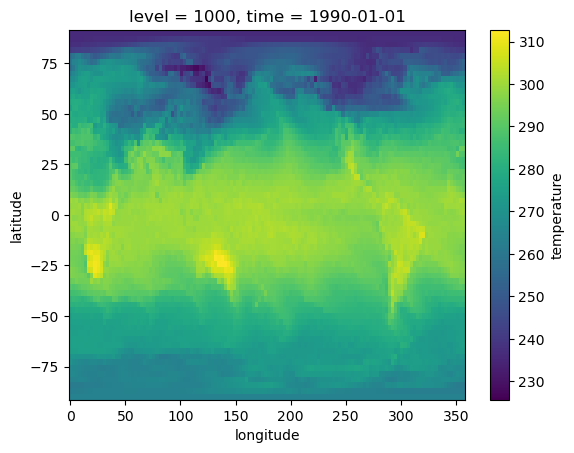

In [19]:
ds["temperature"].sel(time="1990-01-01T00:00:00", level=1000).plot()

In [3]:
def plot_num_nans(dataset):
    for var in dataset.variables:
        print(f"Number of NaNs for {var}: {np.isnan(dataset[var].values.flatten()).sum()}")

Variable: temperature, year: 1990


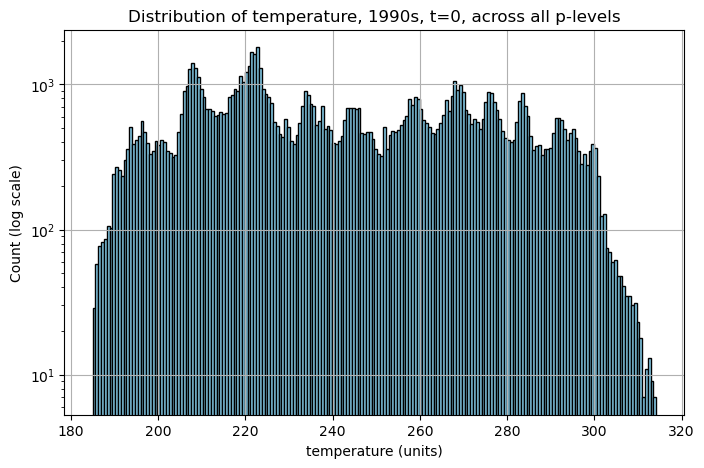

Min: 184.9467888002563
Max: 314.21614305439715
Mean: 242.9596650293743
Std: 30.552631807346614
Number of NaNs: 0
------------------------------



In [ ]:
plot_distribution_per_year(ds, 'temperature', 1990, False)

In [7]:
plot_num_nans(ds.isel(time=slice(-1000, -1)))

Number of NaNs for 10m_u_component_of_wind: 0
Number of NaNs for 10m_v_component_of_wind: 0
Number of NaNs for 2m_temperature: 0
Number of NaNs for geopotential: 0
Number of NaNs for geopotential_at_surface: 0
Number of NaNs for land_sea_mask: 0
Number of NaNs for latitude: 0
Number of NaNs for level: 0
Number of NaNs for longitude: 0
Number of NaNs for mean_sea_level_pressure: 0
Number of NaNs for specific_humidity: 0
Number of NaNs for temperature: 0
Number of NaNs for time: 0
Number of NaNs for total_precipitation_6hr: 0
Number of NaNs for u_component_of_wind: 0
Number of NaNs for v_component_of_wind: 0
Number of NaNs for vertical_velocity: 0


Variable: q, year: 1990


/home/hk-project-pai00005/xo8179/miniconda3/envs/regridding/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


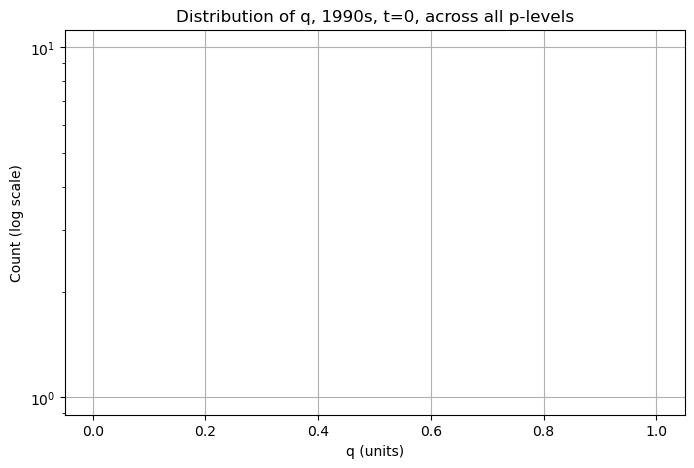

/scratch/ipykernel_2937801/1831434045.py:24: RuntimeWarning: All-NaN slice encountered
  print("Min:", np.nanmin(values))
/scratch/ipykernel_2937801/1831434045.py:25: RuntimeWarning: All-NaN slice encountered
  print("Max:", np.nanmax(values))
/scratch/ipykernel_2937801/1831434045.py:26: RuntimeWarning: Mean of empty slice
  print("Mean:", np.nanmean(values))


Min: nan
Max: nan
Mean: nan


/home/hk-project-pai00005/xo8179/miniconda3/envs/regridding/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Std: nan
Number of NaNs: 25956000
------------------------------

Variable: u, year: 1990


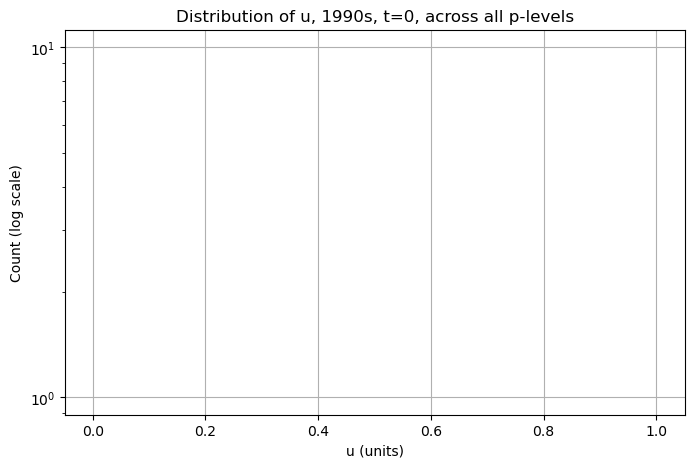

Min: nan
Max: nan
Mean: nan
Std: nan
Number of NaNs: 25956000
------------------------------

Variable: v, year: 1990


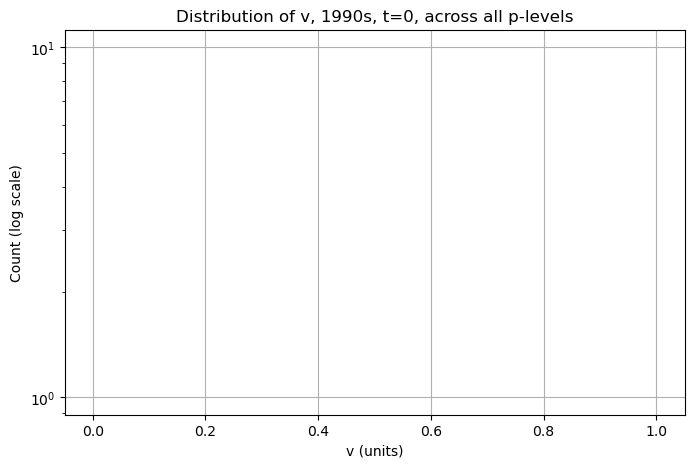

Min: nan
Max: nan
Mean: nan
Std: nan
Number of NaNs: 25956000
------------------------------

Variable: w, year: 1990


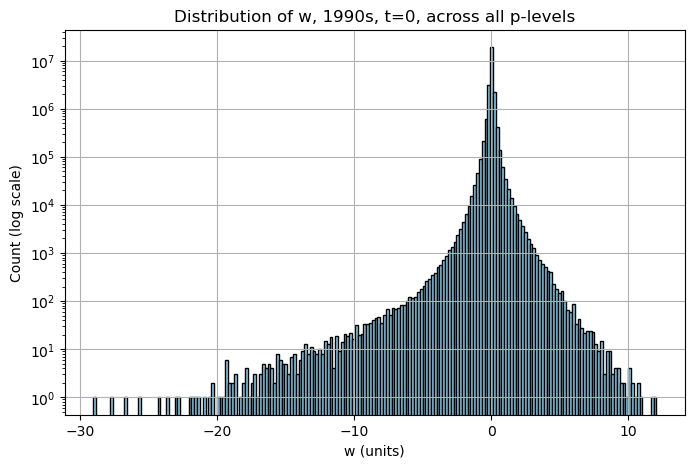

Min: -29.070755004882812
Max: 12.071434020996094
Mean: 0.008629855166803795
Std: 0.23001964276302309
Number of NaNs: 0
------------------------------

Variable: z, year: 1990


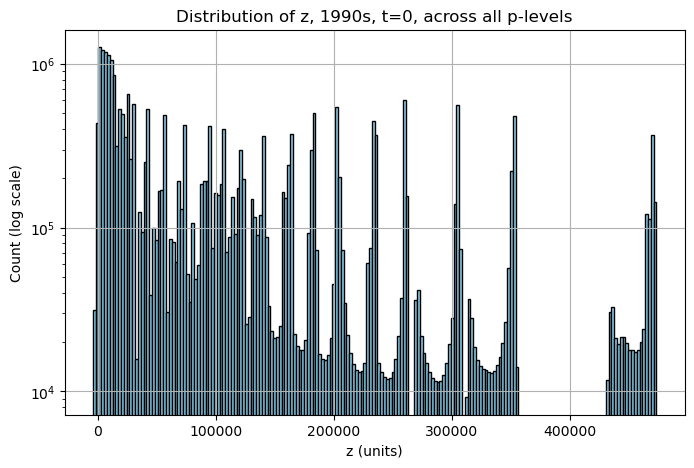

Min: -4009.193115234375
Max: 473322.40234375
Mean: 114238.5299268022
Std: 122254.49946581545
Number of NaNs: 0
------------------------------

Variable: t, year: 1990


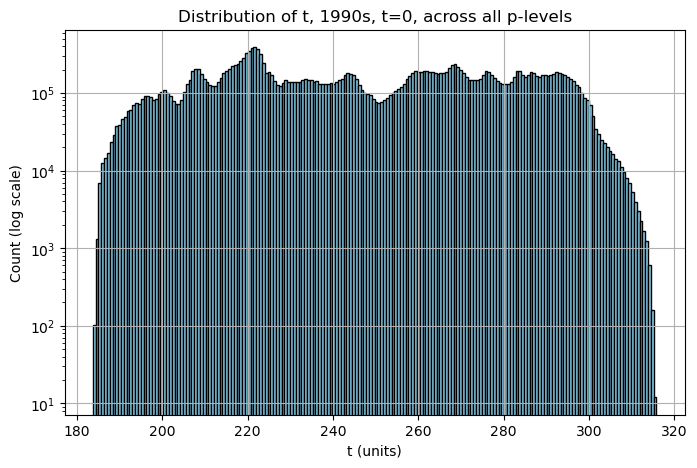

Min: 183.72761154174805
Max: 315.80408477783203
Mean: 247.3924746742347
Std: 30.879936058569537
Number of NaNs: 0
------------------------------

Variable: q, year: 2000


/home/hk-project-pai00005/xo8179/miniconda3/envs/regridding/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


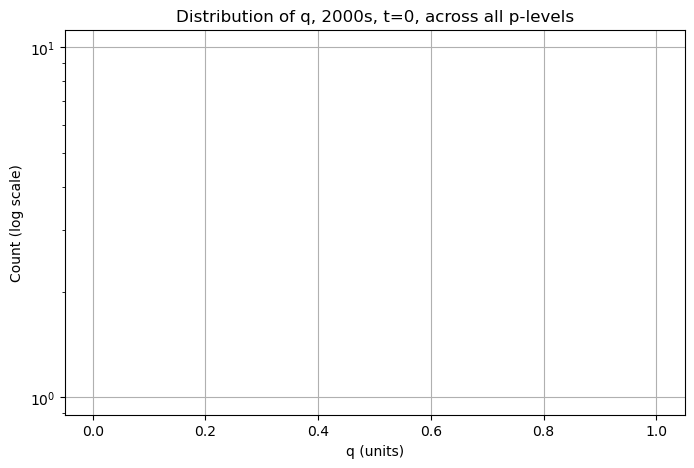

/scratch/ipykernel_2937801/1831434045.py:24: RuntimeWarning: All-NaN slice encountered
  print("Min:", np.nanmin(values))
/scratch/ipykernel_2937801/1831434045.py:25: RuntimeWarning: All-NaN slice encountered
  print("Max:", np.nanmax(values))
/scratch/ipykernel_2937801/1831434045.py:26: RuntimeWarning: Mean of empty slice
  print("Mean:", np.nanmean(values))


Min: nan
Max: nan
Mean: nan


/home/hk-project-pai00005/xo8179/miniconda3/envs/regridding/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Std: nan
Number of NaNs: 25956000
------------------------------

Variable: u, year: 2000


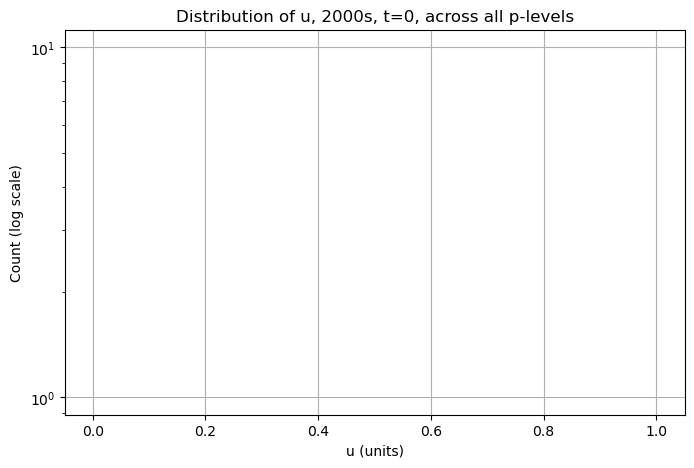

Min: nan
Max: nan
Mean: nan
Std: nan
Number of NaNs: 25956000
------------------------------

Variable: v, year: 2000


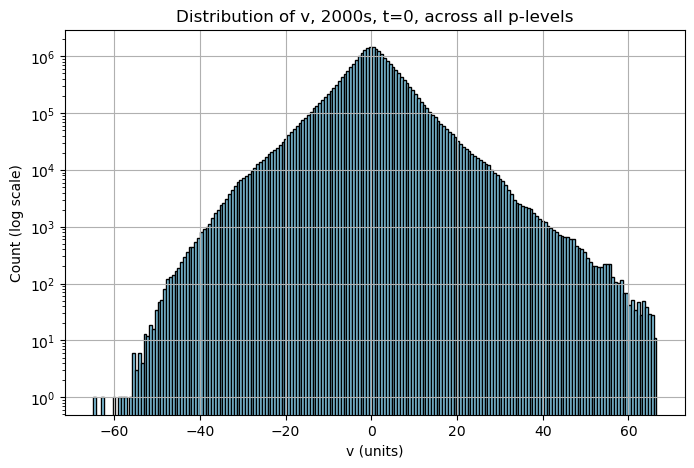

Min: -64.99246215820312
Max: 66.55512237548828
Mean: 0.07280666350392462
Std: 7.432536669486135
Number of NaNs: 0
------------------------------

Variable: w, year: 2000


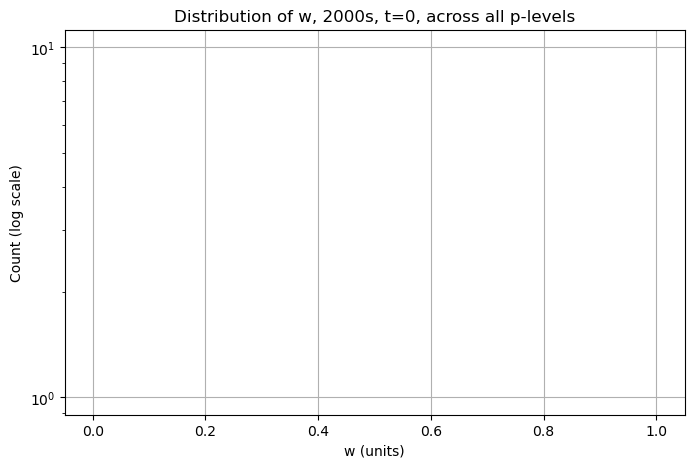

Min: nan
Max: nan
Mean: nan
Std: nan
Number of NaNs: 25956000
------------------------------

Variable: z, year: 2000


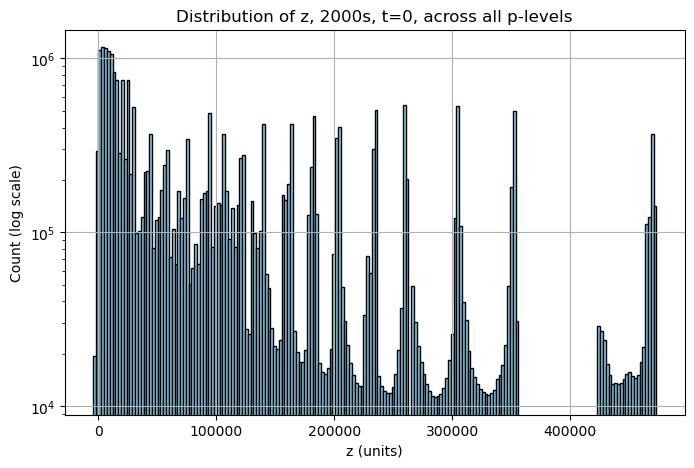

Min: -4610.13037109375
Max: 472967.01953125
Mean: 113884.67856863032
Std: 121877.91982693528
Number of NaNs: 1
------------------------------

Variable: t, year: 2000


/home/hk-project-pai00005/xo8179/miniconda3/envs/regridding/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


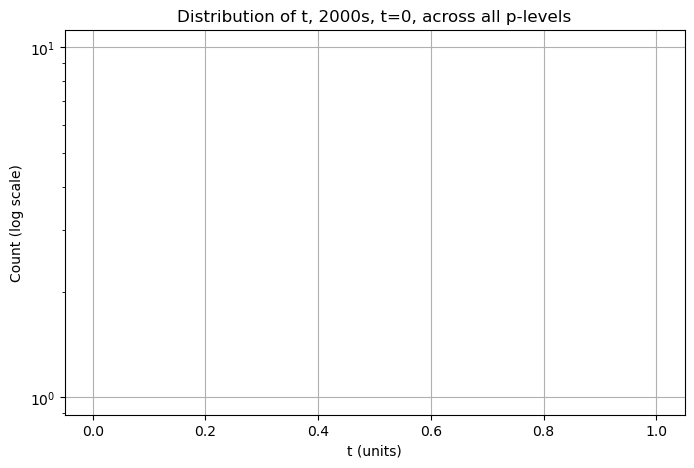

/scratch/ipykernel_2937801/1831434045.py:24: RuntimeWarning: All-NaN slice encountered
  print("Min:", np.nanmin(values))
/scratch/ipykernel_2937801/1831434045.py:25: RuntimeWarning: All-NaN slice encountered
  print("Max:", np.nanmax(values))
/scratch/ipykernel_2937801/1831434045.py:26: RuntimeWarning: Mean of empty slice
  print("Mean:", np.nanmean(values))


Min: nan
Max: nan
Mean: nan


/home/hk-project-pai00005/xo8179/miniconda3/envs/regridding/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Std: nan
Number of NaNs: 25956000
------------------------------

Variable: q, year: 2010


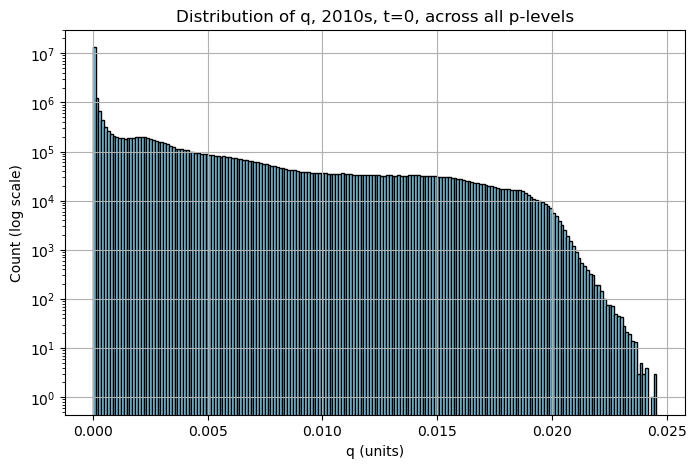

Min: 2.459226777773438e-07
Max: 0.024546976913825347
Mean: 0.002397789817862896
Std: 0.004265754171126463
Number of NaNs: 0
------------------------------

Variable: u, year: 2010


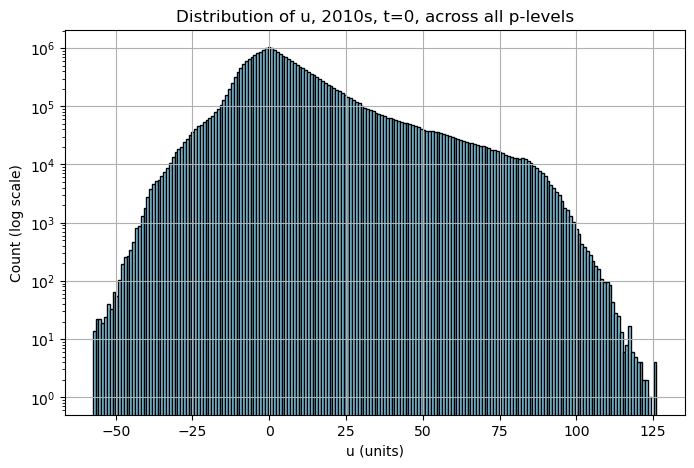

Min: -57.447410583496094
Max: 126.11099243164062
Mean: 6.79719945587923
Std: 17.732181784384622
Number of NaNs: 0
------------------------------

Variable: v, year: 2010


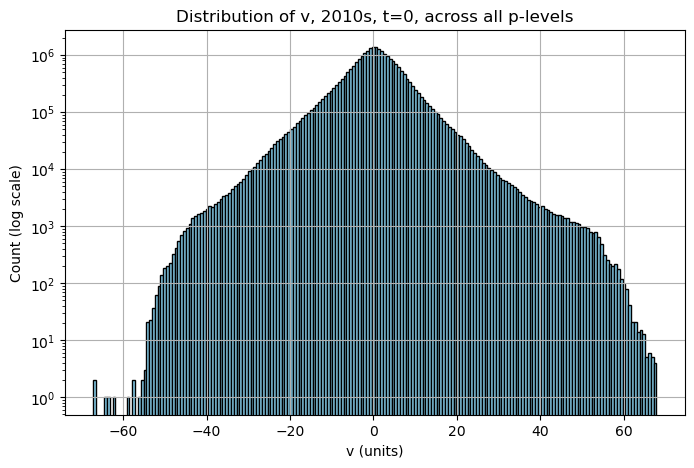

Min: -67.24502563476562
Max: 67.82454681396484
Mean: 0.11271575039475444
Std: 8.072084297247756
Number of NaNs: 0
------------------------------

Variable: w, year: 2010


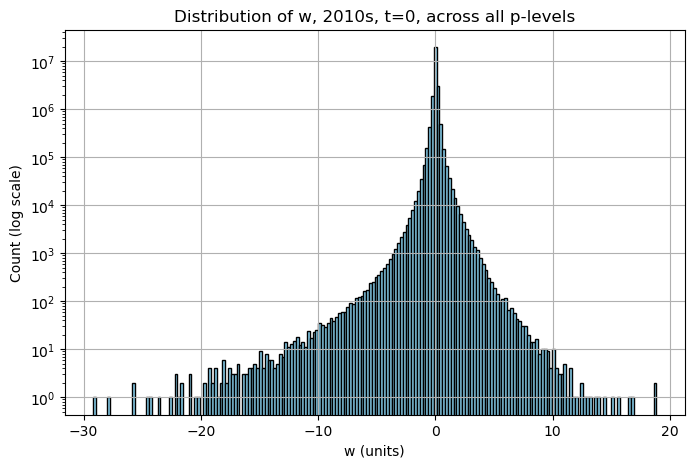

Min: -29.213598251342773
Max: 18.860891342163086
Mean: 0.008475312159935064
Std: 0.25037075380328194
Number of NaNs: 0
------------------------------

Variable: z, year: 2010


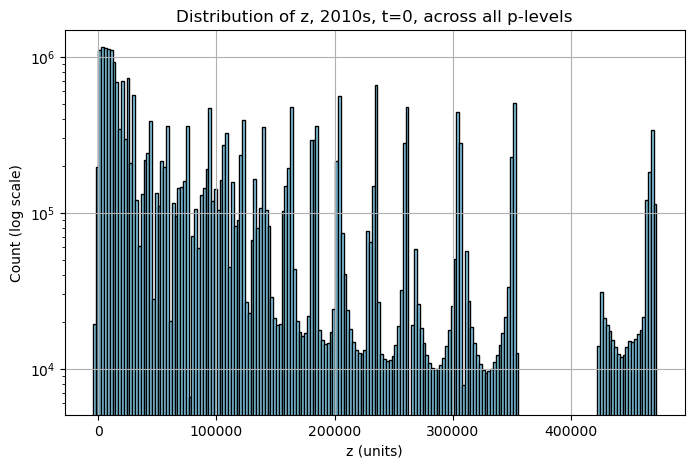

Min: -4662.7734375
Max: 472626.21484375
Mean: 114205.34083814528
Std: 121890.7824972246
Number of NaNs: 0
------------------------------

Variable: t, year: 2010


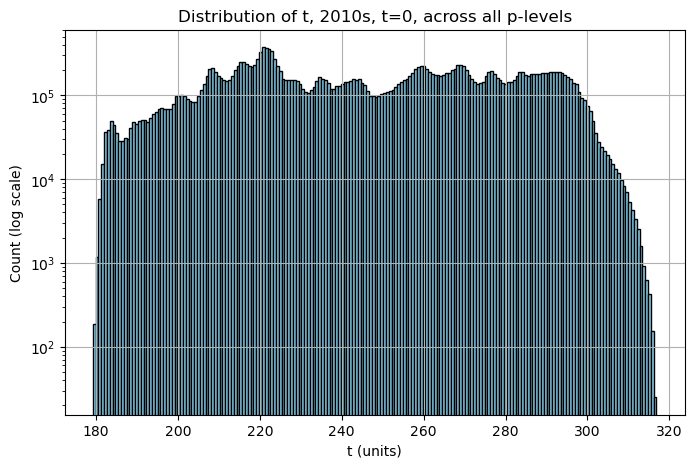

Min: 179.17891311645508
Max: 316.88096618652344
Mean: 247.25789092077645
Std: 31.304778416504487
Number of NaNs: 0
------------------------------



In [ ]:



# Assuming your variable is called 'temperature'
# and your time dimension is 'time'
# Select one day: you may need to adjust indexing
# Here we take the first available time step:
years = [1990, 2000, 2010]
variables = [
    'q','u','v','w','z','t'
    ]
for year in years:
    ds_time = xr.open_dataset(base+f"3D_nextgems_{year}s_6hourly_0.25deg_t.nc", chunks={"time": 16})['time']
    for variable in variables:
        
        if not variable == "t":
            ds = xr.open_dataset(base+f"3D_nextgems_{year}s_6hourly_0.25deg_{variable}.nc", decode_times=False, chunks={"time": 16})
            ds['time'] = ds_time
        else:
            ds = xr.open_dataset(base+f"3D_nextgems_{year}s_6hourly_0.25deg_{variable}.nc", chunks={"time": 16})
        plot_distribution_per_year(ds, variable, year, False)
        

Variable: 10u, year: 1990


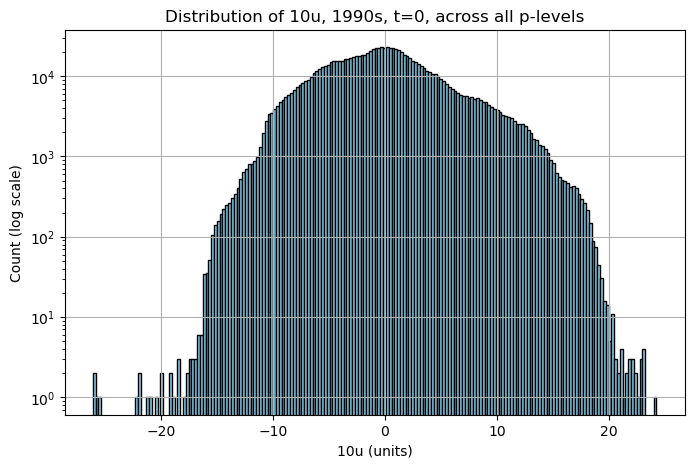

Min: -26.052505493164062
Max: 24.203784942626953
Mean: -0.09067232055461247
Std: 5.374180102394931
Number of NaNs: 0
------------------------------

Variable: 10v, year: 1990


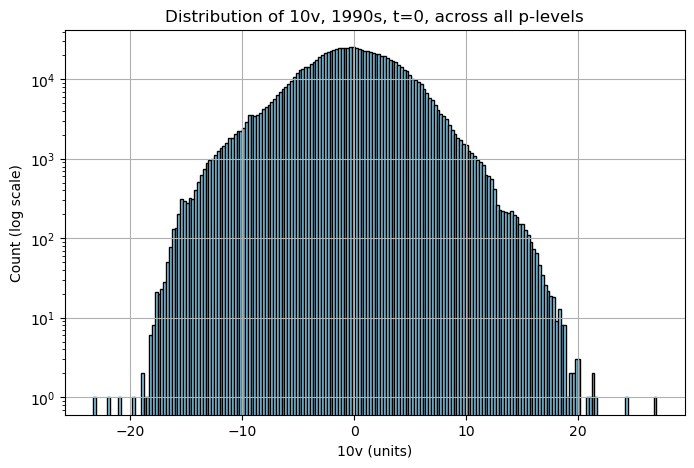

Min: -23.3579158782959
Max: 27.030569076538086
Mean: -0.30267275370293467
Std: 4.4763146614368114
Number of NaNs: 0
------------------------------

Variable: 2t, year: 1990


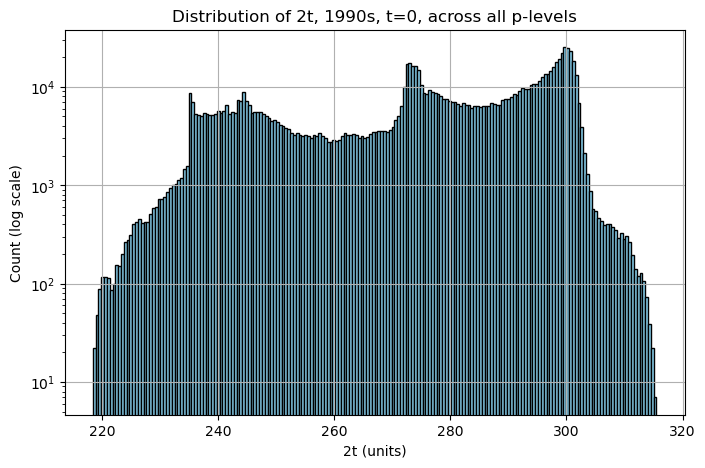

Min: 218.4245376586914
Max: 315.4962463378906
Mean: 275.7614177129654
Std: 21.326602095295858
Number of NaNs: 0
------------------------------

Variable: msl, year: 1990


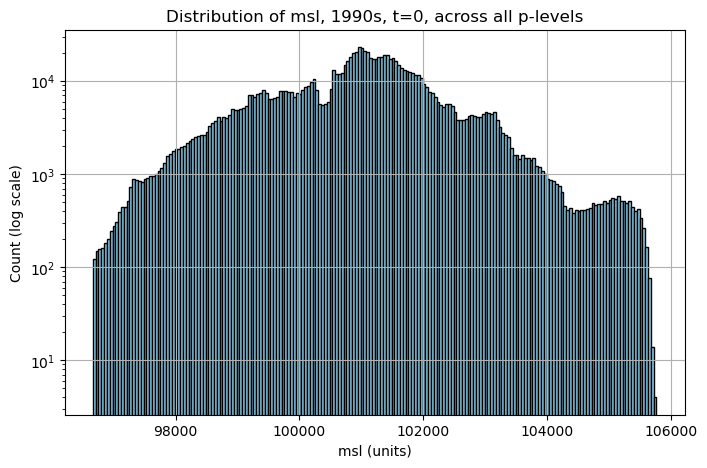

Min: 96659.6240234375
Max: 105770.00390625
Mean: 100946.64536547802
Std: 1372.8396674838934
Number of NaNs: 0
------------------------------



In [ ]:
for var in ['10u','10v','2t','msl']:
    ds = xr.open_dataset(base+f"surface_nextgems_1990s_2020_6hourly_0.25deg_surface_uvtmsl.nc", chunks={"time": 16})
    plot_distribution_per_year(ds, var, '1990', savefig=False)

In [ ]:

ds = xr.open_dataset(base+f"surface_nextgems_1990s_2020_allhours_0.25deg_total_precipitation_new.nc", chunks={"time": 16}).isel(time=slice(1,-1))
plot_distribution_per_year(ds, 'tp', '1990', savefig=False)

NameError: name 'plot_var' is not defined

In [14]:
import pandas as pd
# Select the precipitation variable
# Replace 'precip' with your actual variable name
ds = xr.open_dataset(base+f"surface_nextgems_1990s_2020_allhours_0.25deg_total_precipitation_new.nc", chunks={"time": 16})
da = ds['tp']
print(da)

# Count NaNs across all spatial dimensions for each time step
nan_counts_per_timestep = da.isnull().sum(dim="value")


<xarray.DataArray 'tp' (time: 262969, value: 1038240)> Size: 2TB
dask.array<open_dataset-tp, shape=(262969, 1038240), dtype=float64, chunksize=(16, 1038240), chunktype=numpy.ndarray>
Coordinates:
    lat      (value) float64 8MB dask.array<chunksize=(1038240,), meta=np.ndarray>
    lon      (value) float64 8MB dask.array<chunksize=(1038240,), meta=np.ndarray>
  * time     (time) datetime64[ns] 2MB 1990-01-01 ... 2020-01-01
Dimensions without coordinates: value
Attributes: (12/14)
    paramId:                    228
    dataType:                   fc
    numberOfPoints:             1038240
    typeOfLevel:                surface
    stepUnits:                  1
    stepType:                   accum
    ...                         ...
    units:                      m
    name:                       Total precipitation
    cfVarName:                  tp
    missingValue:               9999
    NV:                         0
    gridDefinitionDescription:  Latitude/longitude


In [15]:
print(nan_counts_per_timestep)

<xarray.DataArray 'tp' (time: 262969)> Size: 2MB
dask.array<sum-aggregate, shape=(262969,), dtype=int64, chunksize=(16,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2MB 1990-01-01 ... 2020-01-01


In [16]:
print(da.isel(time=0).values)

[nan nan nan ... nan nan nan]


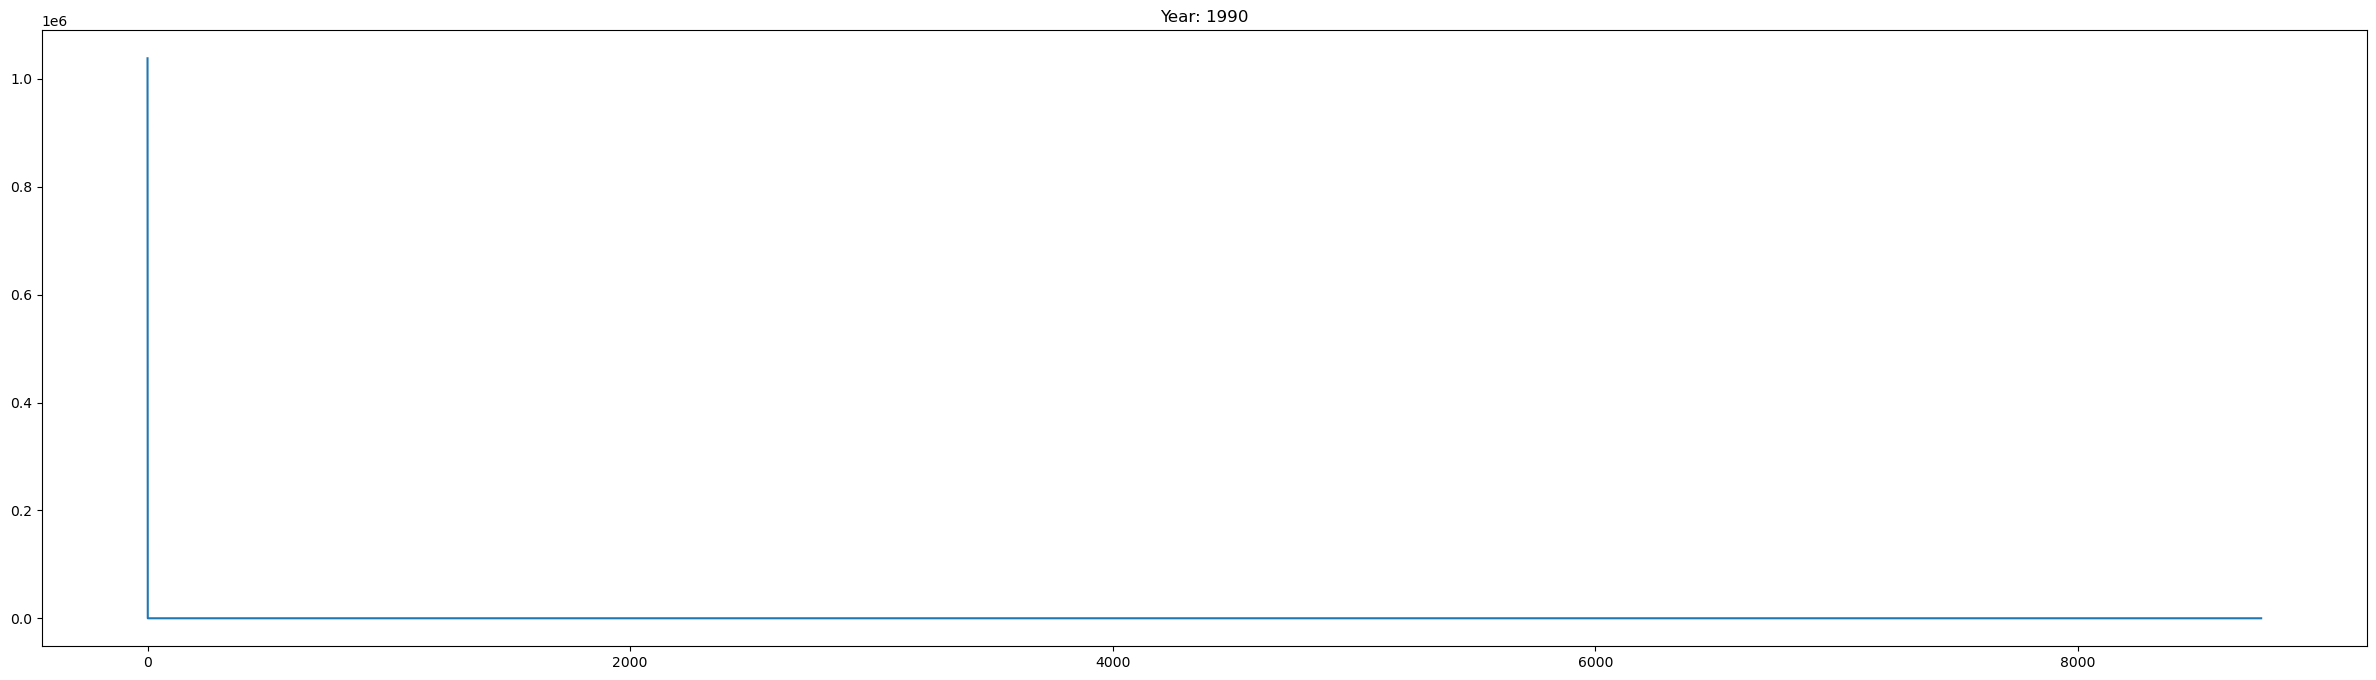

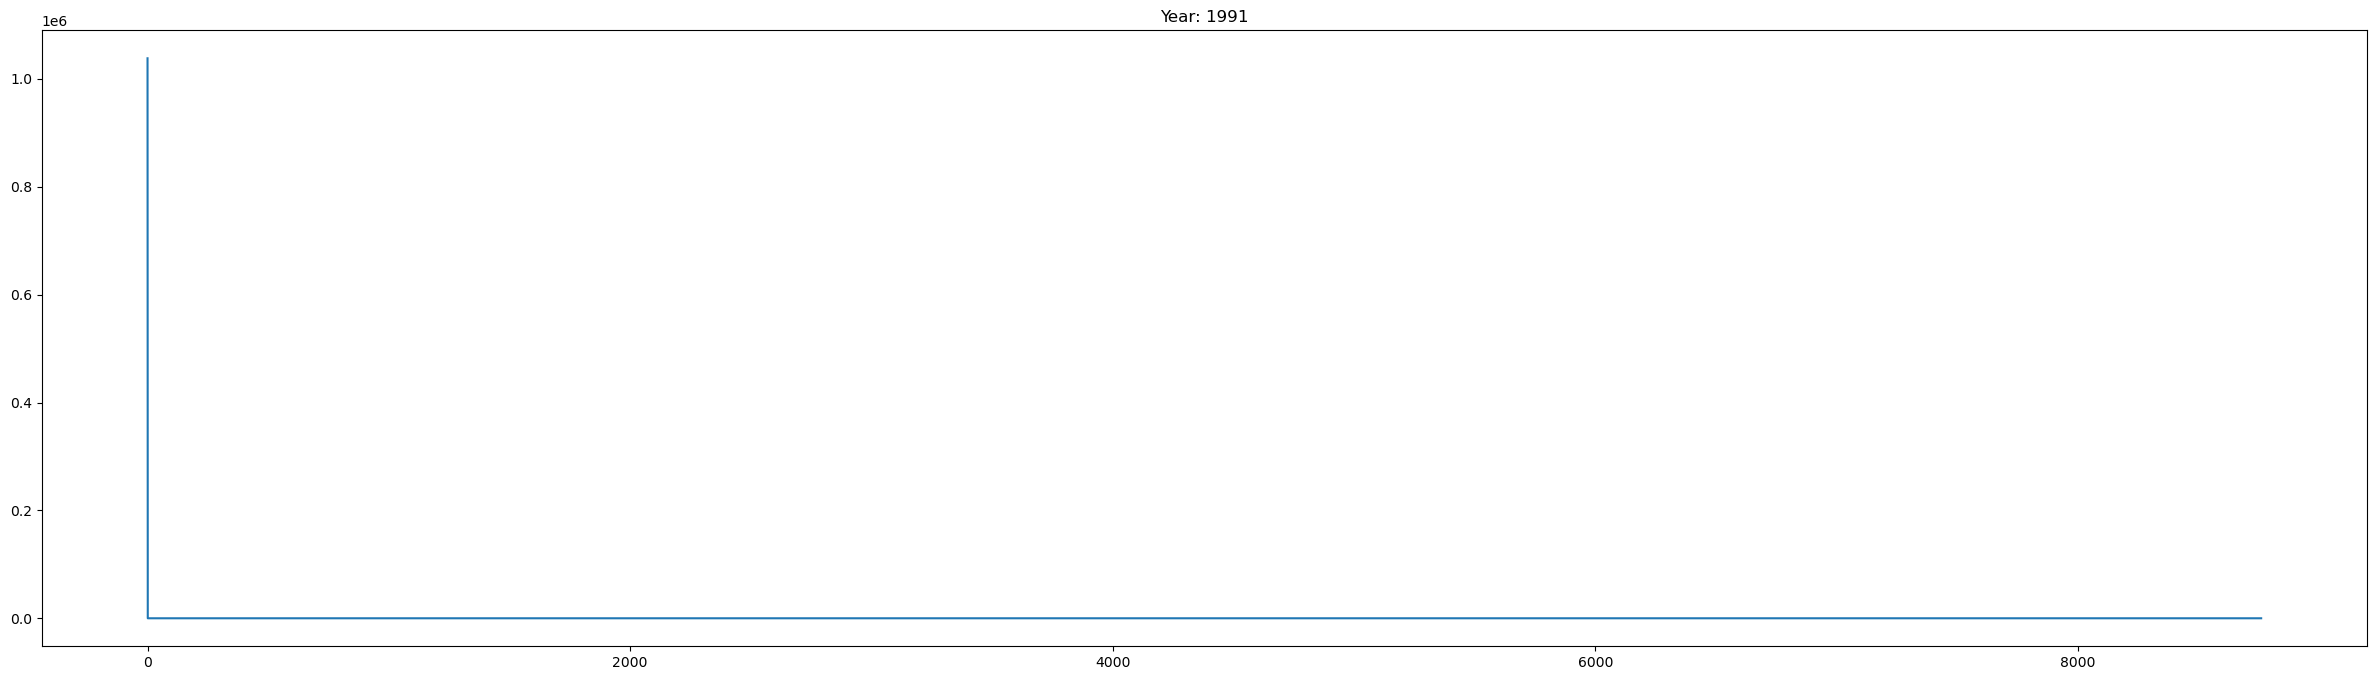

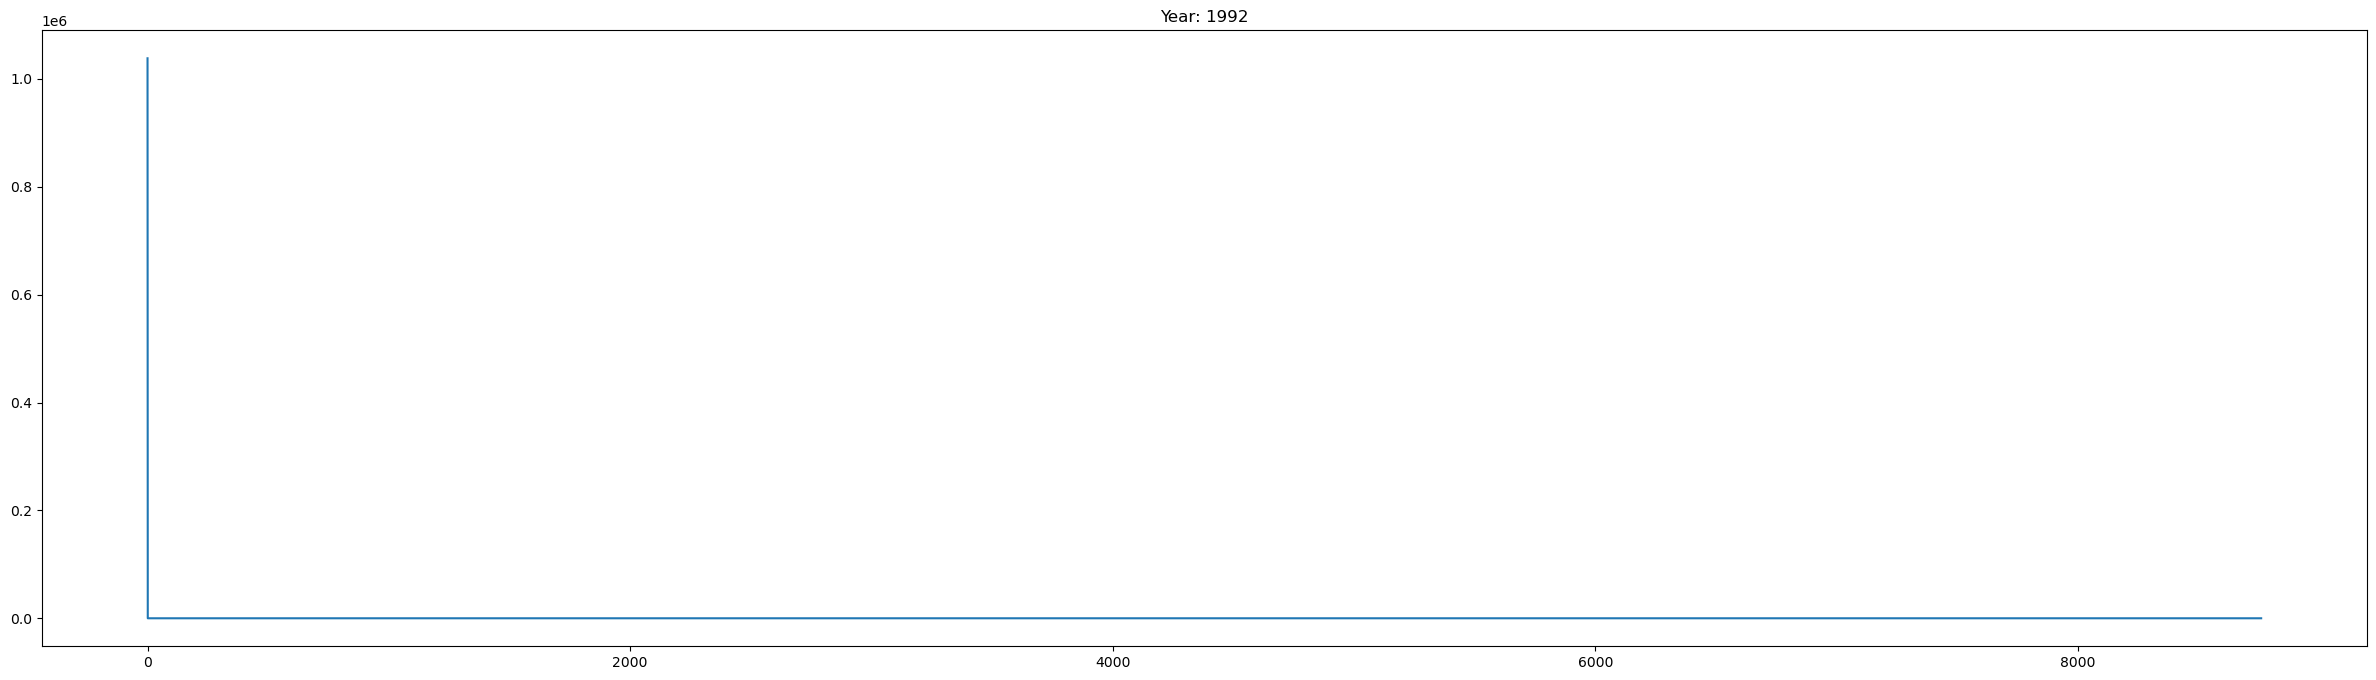

KeyboardInterrupt: 

In [23]:
for i in range(30):
    if (np.sum(nan_counts_per_timestep[i*24*365:(i+1)*24*365])>0):
        plt.figure(figsize=(30, 8))
        plt.plot(nan_counts_per_timestep[i*24*365:(i+1)*24*365])
        plt.title(f"Year: {1990+i}")
        plt.show()

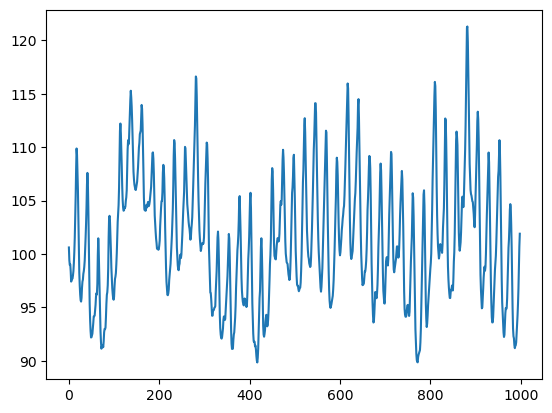

In [26]:
da = ds['tp'].isel(time=slice(1, 1000))
plt.plot(da.sum(dim="value").values)

In [ ]:
for i in [0, 6, 12, 18, 24]:
    plt.figure(figsize=(30, 8))
    plt.plot(nan_counts_per_timestep[i*4*365:(i+1)*4*365])
    plt.title(f"Year: {1990+i}")
    plt.show()

# years with nans: 1990, 1996, 2002, 2008, 2014

In [20]:
for i in [0, 6, 12, 18, 24]:
    for j in range(60):
        if nan_counts_per_timestep[i*4*365+j] > 0:
            print(f"encountered {nan_counts_per_timestep[i*4*365+j].values} at timestep {i*4*365+j}")

encountered 1038240 at timestep 0
encountered 1038240 at timestep 8760
encountered 1038240 at timestep 17520
encountered 1038240 at timestep 26304
encountered 1038240 at timestep 35064


In [21]:
print(da['time'][:10])

<xarray.DataArray 'time' (time: 10)> Size: 80B
array(['1990-01-01T00:00:00.000000000', '1990-01-01T01:00:00.000000000',
       '1990-01-01T02:00:00.000000000', '1990-01-01T03:00:00.000000000',
       '1990-01-01T04:00:00.000000000', '1990-01-01T05:00:00.000000000',
       '1990-01-01T06:00:00.000000000', '1990-01-01T07:00:00.000000000',
       '1990-01-01T08:00:00.000000000', '1990-01-01T09:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 80B 1990-01-01 ... 1990-01-01T09:00:00
